# Forecasting Indikator Kesehatan Mental Nasional (2019–2024)
### Kelanjutan Metodologi Fase 2 (Tuning & Pemilihan Model) & Fase 3 (Robustness & Forecast)

**Unit analisis:** 72 titik bulanan, Januari 2019 – Desember 2024 · **Keluaran:** proyeksi 24 bulan + SVG vektor

| Variabel | Deskripsi | Peran |
|---|---|---|
| `volume_konsultasi_mental` | Volume konsultasi kesehatan mental per bulan | **Target utama** |
| `indeks_stres_finansial` | Indeks stres finansial & pekerjaan (skala 0–100) | Kandidat regressor eksogen |
| `indeks_burnout_pekerja` | Indeks burnout generasi muda/pekerja (skala 0–100) | Kandidat regressor eksogen |
| `panggilan_krisis_psikologis` | Panggilan layanan krisis per bulan | Target sekunder — **bukan** regressor (lihat Bagian 3) |

**Perbedaan konteks vs Fase 2/3 (energi, tahunan):** data ini **bulanan** (musiman tahunan
relevan, bukan hanya tren), dan mengandung **lonjakan struktural COVID-19** sejak Maret 2020
yang bentuknya eksponensial, bukan sekadar pulsa satu titik. Karena itu kerangka Fase 2/3
dipertahankan (walk-forward CV, uji struktur break, ensemble, fan chart) tetapi setiap
komponen disesuaikan: model kandidat memakai varian musiman (SARIMA, Holt-Winters, Prophet),
dan sebelum pemodelan ditambahkan dekomposisi STL, uji stasioneritas formal, serta diagnostik
kebocoran data (Bagian 3) yang tidak relevan untuk seri tahunan tunggal di Fase 2/3.

## 0. Setup & Dependencies

In [1]:
# Jika belum terpasang, jalankan sekali:
# !pip install pandas numpy statsmodels scipy scikit-learn matplotlib prophet openpyxl

import warnings; warnings.filterwarnings('ignore')
import os, logging, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

logging.getLogger('statsmodels').setLevel(logging.ERROR)
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)
logging.getLogger('prophet').setLevel(logging.ERROR)
try:
    from prophet import Prophet
    ADA_PROPHET = True
except Exception:
    ADA_PROPHET = False

PALETTE = {'primary':'#2a78d6','secondary':'#1baf7a','accent':'#eda100','danger':'#e34948',
          'muted':'#8a8780','dark':'#2c2c2a','low':'#7fb3e8','high':'#1c5fae','purple':'#9b59b6'}
plt.rcParams.update({'figure.dpi':115,'axes.grid':True,'grid.alpha':0.25,
                     'axes.facecolor':'#fafaf8','font.size':10,'axes.titleweight':'semibold',
                     'svg.fonttype':'none'})
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

SVG_DIR = 'figures_svg'
os.makedirs(SVG_DIR, exist_ok=True)
print(f'Setup OK | Prophet tersedia: {ADA_PROPHET} | Folder SVG: {os.path.abspath(SVG_DIR)}')

Importing plotly failed. Interactive plots will not work.


Setup OK | Prophet tersedia: True | Folder SVG: /home/claude/mental_build/figures_svg


## 1. Memuat Data

Sumber: `dataset_forecasting_kesehatan_mental_72bulan.csv` — 72 observasi bulanan, tanpa data hilang.

In [2]:
m = pd.read_csv('dataset_forecasting_kesehatan_mental_72bulan.csv', parse_dates=['tanggal'])
m = m.set_index('tanggal').asfreq('MS')
KOLOM = ['volume_konsultasi_mental','indeks_stres_finansial',
         'panggilan_krisis_psikologis','indeks_burnout_pekerja']
LABEL = {'volume_konsultasi_mental':'Volume Konsultasi Mental',
         'indeks_stres_finansial':'Indeks Stres Finansial',
         'panggilan_krisis_psikologis':'Panggilan Layanan Krisis',
         'indeks_burnout_pekerja':'Indeks Burnout Pekerja'}
Y_COL = 'volume_konsultasi_mental'

print('Periode  :', m.index.min().strftime('%Y-%m'), '-', m.index.max().strftime('%Y-%m'))
print('N        :', len(m), '| data hilang:', int(m[KOLOM].isna().sum().sum()))
display(m[KOLOM].describe().T.round(2))
m.head()

Periode  : 2019-01 - 2024-12
N        : 72 | data hilang: 0


,count,mean,std,min,25%,50%,75%,max
volume_konsultasi_mental,72.000,"19,826.240","12,837.120","2,670.000","9,807.750","17,375.000","29,209.000","48,445.000"
indeks_stres_finansial,72.000,60.770,6.620,47.170,55.660,61.190,64.520,76.540
panggilan_krisis_psikologis,72.000,"3,194.030","1,549.120","1,109.000","2,016.000","2,952.500","4,218.000","6,544.000"
indeks_burnout_pekerja,72.000,60.900,9.630,43.840,52.230,61.360,69.230,78.850


,volume_konsultasi_mental,indeks_stres_finansial,panggilan_krisis_psikologis,indeks_burnout_pekerja
tanggal,,,,
2019-01-01,2699,51.940,1145,43.840
2019-02-01,2670,58.070,1313,45.100
2019-03-01,3210,52.980,1216,45.170
2019-04-01,3785,60.230,1149,46.470
2019-05-01,3308,58.350,1109,50.270


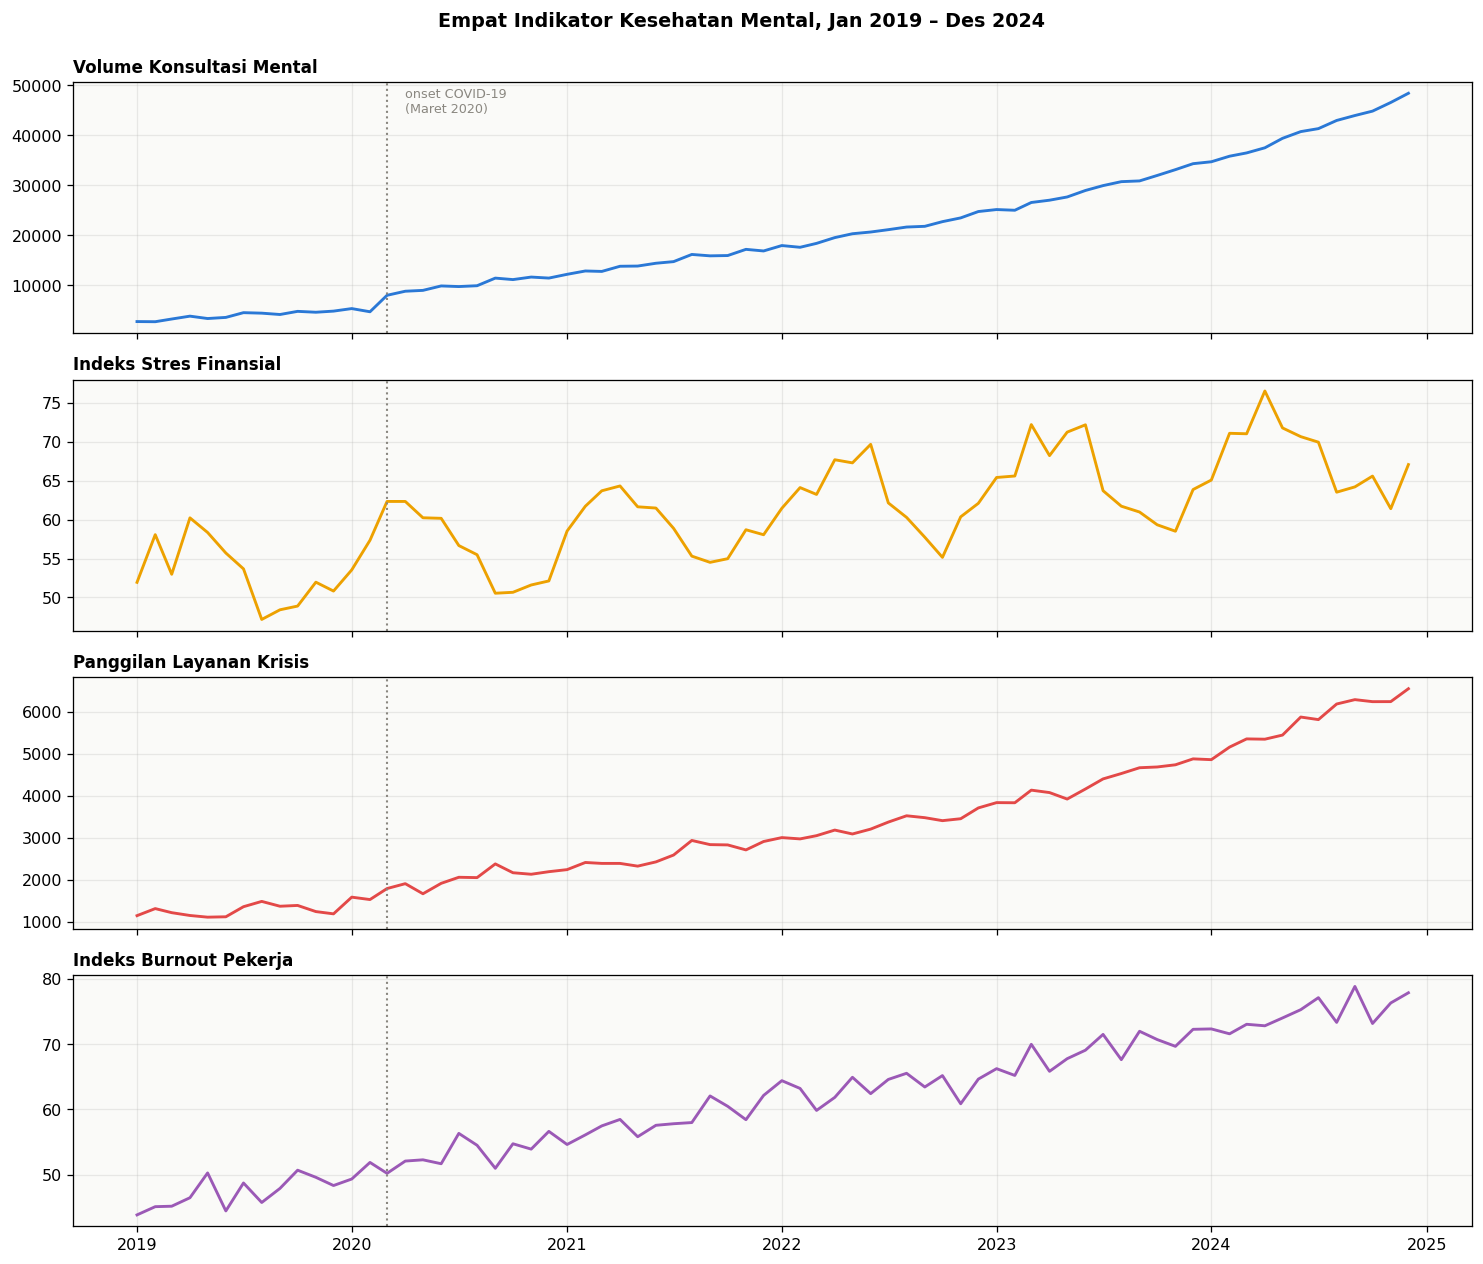

In [3]:
fig, axes = plt.subplots(4, 1, figsize=(13, 11), sharex=True)
warna = [PALETTE['primary'], PALETTE['accent'], PALETTE['danger'], PALETTE['purple']]
for ax, c, w in zip(axes, KOLOM, warna):
    ax.plot(m.index, m[c], color=w, lw=1.8)
    ax.axvline(pd.Timestamp('2020-03-01'), color=PALETTE['muted'], ls=':', lw=1.3)
    ax.set_title(LABEL[c], fontsize=10.5, loc='left')
axes[0].text(pd.Timestamp('2020-04-01'), m[Y_COL].max()*.92, 'onset COVID-19\n(Maret 2020)',
             fontsize=8, color=PALETTE['muted'])
fig.suptitle('Empat Indikator Kesehatan Mental, Jan 2019 – Des 2024', fontweight='bold', y=.995)
plt.tight_layout()
fig.savefig(f'{SVG_DIR}/00_empat_seri.svg', format='svg', bbox_inches='tight')
plt.show()

## 2. Dekomposisi dan Stasioneritas

Sebelum menentukan orde SARIMA, tren, musiman, dan kebutuhan differencing diperiksa
secara formal — langkah yang tidak diperlukan di Fase 2/3 karena data tahunan di sana
tidak bermusim.

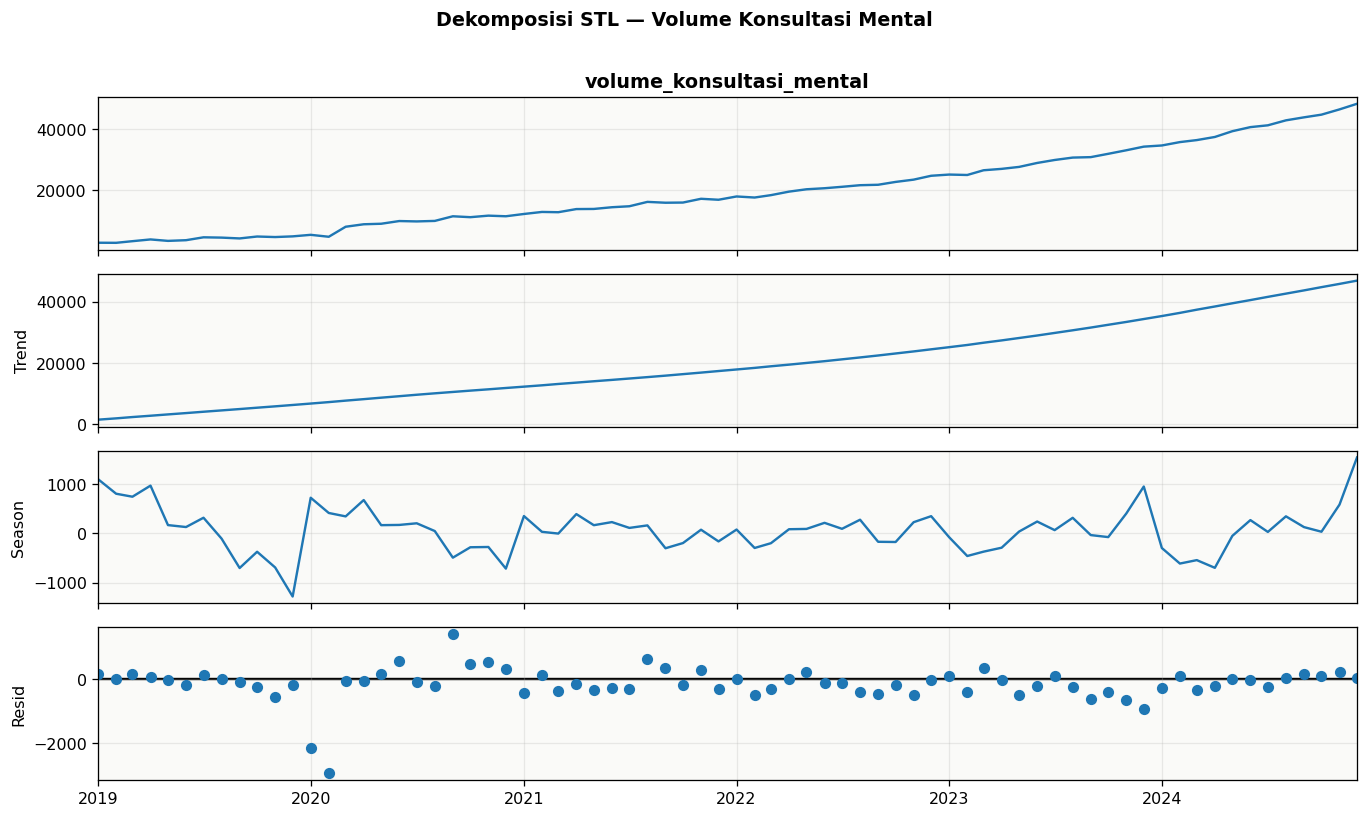

Kekuatan tren    : 0.998  (>0.6 = tren kuat)
Kekuatan musiman : 0.311  (>0.6 = musiman kuat)


In [4]:
stl = STL(m[Y_COL], period=12, robust=True).fit()
fig = stl.plot(); fig.set_size_inches(12, 7)
fig.suptitle(f'Dekomposisi STL — {LABEL[Y_COL]}', fontweight='bold', y=1.01)
plt.tight_layout()
fig.savefig(f'{SVG_DIR}/01_stl_dekomposisi.svg', format='svg', bbox_inches='tight')
plt.show()

kekuatan_musim = max(0, 1 - stl.resid.var()/(stl.seasonal+stl.resid).var())
kekuatan_tren  = max(0, 1 - stl.resid.var()/(stl.trend+stl.resid).var())
print(f'Kekuatan tren    : {kekuatan_tren:.3f}  (>0.6 = tren kuat)')
print(f'Kekuatan musiman : {kekuatan_musim:.3f}  (>0.6 = musiman kuat)')

In [5]:
def uji_stasioner(s, nama):
    adf_p  = adfuller(s.dropna(), autolag='AIC')[1]
    kpss_p = kpss(s.dropna(), regression='c', nlags='auto')[1]
    print(f'{nama:28s} ADF p={adf_p:.4f} ({"stasioner" if adf_p<.05 else "non-stasioner"})  '
          f'| KPSS p={kpss_p:.4f} ({"stasioner" if kpss_p>.05 else "non-stasioner"})')

ly = np.log(m[Y_COL])
uji_stasioner(ly, 'Level (log)')
uji_stasioner(ly.diff().dropna(), 'Differencing d=1')
uji_stasioner(ly.diff().diff(12).dropna(), 'Differencing d=1, D=1 (s=12)')

D_ORDER, d_ORDER = 1, 1
print(f'\nOrde differencing dipakai: d={d_ORDER} (tren), D={D_ORDER} (musiman, s=12)')

Level (log)                  ADF p=0.1590 (non-stasioner)  | KPSS p=0.0100 (non-stasioner)
Differencing d=1             ADF p=0.0000 (stasioner)  | KPSS p=0.0922 (stasioner)
Differencing d=1, D=1 (s=12) ADF p=0.1066 (non-stasioner)  | KPSS p=0.1000 (stasioner)

Orde differencing dipakai: d=1 (tren), D=1 (musiman, s=12)


/tmp/ipykernel_480/2666516371.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  kpss_p = kpss(s.dropna(), regression='c', nlags='auto')[1]
/tmp/ipykernel_480/2666516371.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kpss_p = kpss(s.dropna(), regression='c', nlags='auto')[1]


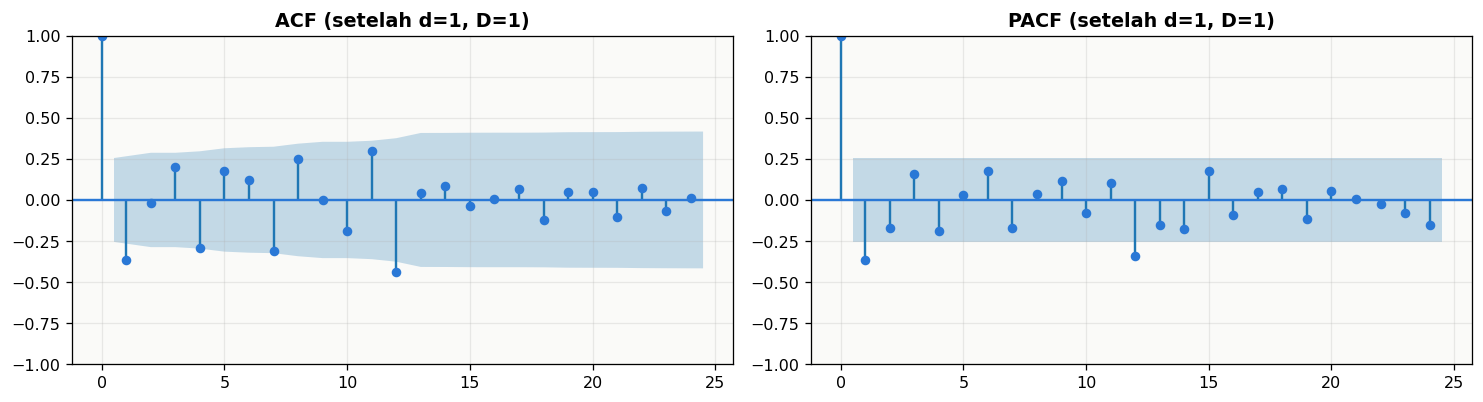

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))
seri_diff = ly.diff().diff(12).dropna()
plot_acf(seri_diff, lags=24, ax=axes[0], color=PALETTE['primary'])
plot_pacf(seri_diff, lags=24, ax=axes[1], color=PALETTE['primary'], method='ywm')
axes[0].set_title('ACF (setelah d=1, D=1)'); axes[1].set_title('PACF (setelah d=1, D=1)')
plt.tight_layout(); plt.show()

## 3. Korelasi Antarindikator dan Diagnostik Kebocoran Data

Sebelum memilih regressor eksogen, keterkaitan antarindikator diperiksa — mengikuti
semangat pengecekan multikolinearitas pada analisis JALA sebelumnya, tetapi di sini
persoalannya lebih mendasar: **kebocoran data (data leakage)**, bukan sekadar korelasi tinggi.

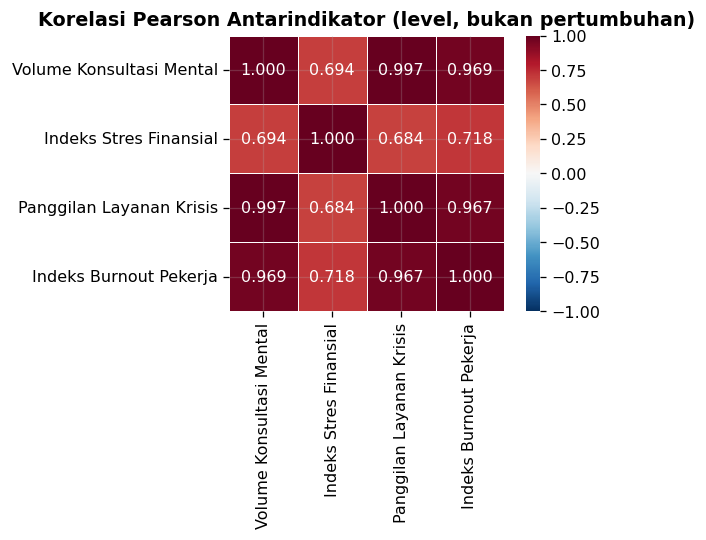

Korelasi Panggilan Layanan Krisis dgn Volume Konsultasi Mental (kontemporer): 0.997


In [7]:
kor = m[KOLOM].corr()
plt.figure(figsize=(6, 4.8))
import seaborn as sns
sns.heatmap(kor, annot=True, fmt='.3f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=.5, xticklabels=[LABEL[c] for c in KOLOM],
            yticklabels=[LABEL[c] for c in KOLOM])
plt.title('Korelasi Pearson Antarindikator (level, bukan pertumbuhan)')
plt.tight_layout(); plt.show()

print(f"Korelasi {LABEL['panggilan_krisis_psikologis']} dgn {LABEL[Y_COL]} (kontemporer): "
      f"{kor.loc['panggilan_krisis_psikologis', Y_COL]:.3f}")

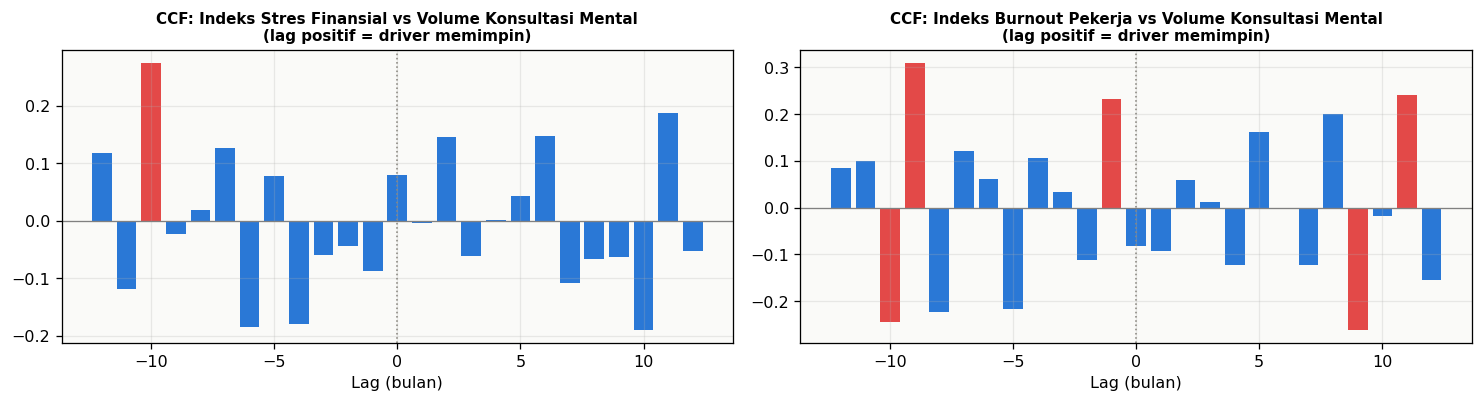

Tafsir: |CCF| di bawah ~0.23 (ambang kasar 2/sqrt(N)) tidak berbeda nyata dari nol.


In [8]:
# Cross-correlation function: apakah stres/burnout memimpin (leading) volume konsultasi,
# atau hanya sama-sama mengikuti tren umum? Dihitung pada seri yang sudah dibuang trennya
# (differencing 1x) supaya tren bersama tidak mendominasi angka korelasi.
def ccf_dibuang_tren(x, y, maks_lag=12):
    """corr(x_t, y_{t+lag}): lag positif berarti x (driver) mendahului y (target)."""
    xs, ys = x.diff().dropna(), y.diff().dropna()
    xs, ys = xs.align(ys, join='inner')
    lags = range(-maks_lag, maks_lag + 1)
    return pd.Series({lag: xs.corr(ys.shift(-lag)) for lag in lags})

fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))
for ax, driver in zip(axes, ['indeks_stres_finansial', 'indeks_burnout_pekerja']):
    c = ccf_dibuang_tren(m[driver], m[Y_COL])
    ax.bar(c.index, c.values, color=[PALETTE['danger'] if abs(v) > 0.23 else PALETTE['primary'] for v in c.values])
    ax.axhline(0, color='grey', lw=.8); ax.axvline(0, color=PALETTE['muted'], ls=':', lw=1)
    ax.set_title(f'CCF: {LABEL[driver]} vs {LABEL[Y_COL]}\n(lag positif = driver memimpin)', fontsize=9.5)
    ax.set_xlabel('Lag (bulan)')
plt.tight_layout(); plt.show()
print('Tafsir: |CCF| di bawah ~0.23 (ambang kasar 2/sqrt(N)) tidak berbeda nyata dari nol.')

**Keputusan regressor eksogen.**

- `panggilan_krisis_psikologis` **dikeluarkan** dari daftar regressor untuk memprediksi
  `volume_konsultasi_mental`. Korelasi kontemporernya tinggi bukan karena hubungan
  prediktif yang berguna, melainkan **kebocoran data**: nilainya baru diketahui pada
  bulan yang sama dengan target, sehingga tidak bisa dipakai secara jujur untuk
  meramalkan bulan itu sendiri. Ia diperlakukan sebagai **target sekunder** sendiri
  di Bagian 9, diramalkan dengan metodenya sendiri.
- `indeks_stres_finansial` dan `indeks_burnout_pekerja` dipertahankan sebagai kandidat
  regressor eksogen. Keduanya tersedia lebih dulu secara operasional (survei/indeks
  bulanan yang dirilis independen dari volume konsultasi), dan CCF di atas tidak
  menunjukkan bukti kebocoran kontemporer yang sama kuatnya. Nilai tambahnya terhadap
  akurasi tetap **diuji secara empiris** lewat walk-forward CV di Bagian 6, bukan diasumsikan.

## 4. Fungsi Bantu

In [9]:
def mape(yt, yp):
    yt, yp = np.array(yt), np.array(yp)
    return np.mean(np.abs((yt - yp) / yt)) * 100

def rmse(yt, yp):
    yt, yp = np.array(yt), np.array(yp)
    return np.sqrt(np.mean((yt - yp) ** 2))

def smape(yt, yp):
    yt, yp = np.array(yt), np.array(yp)
    return np.mean(2 * np.abs(yt - yp) / (np.abs(yt) + np.abs(yp))) * 100

def forecast_exog(series, h, freq='MS'):
    """Ramalkan regressor eksogen sendiri (Holt-Winters teredam), dibatasi [0,100]
    karena keduanya adalah indeks skala 0-100. Menggantikan extrapolate() log-linear
    di Fase 2 -- yang tidak menangani musiman."""
    fit = ExponentialSmoothing(series, trend='add', damped_trend=True,
                               seasonal='add', seasonal_periods=12).fit()
    fc = fit.forecast(h)
    return np.clip(fc.values, 0, 100)

print('Helper metrik & forecast_exog siap.')

Helper metrik & forecast_exog siap.


## 5. Definisi Model Kandidat

Tujuh kandidat diuji, setara semangat tabel model Fase 2 tetapi disesuaikan untuk data
bulanan bermusim: baseline naif musiman & drift, dua model musiman klasik (ETS, SARIMA),
satu model berdriver (SARIMAX + regressor eksogen yang diramalkan sendiri), Prophet
(dipilih karena menangani tren + musiman + potensi structural break sekaligus -- selaras
dengan pemakaiannya di Fase 1 proyek energi), dan ensemble.

In [10]:
def m_seasonal_naive(train, h, **kw):
    """Baseline: nilai h bulan lalu pada periode musiman yang sama, ditambah drift tren."""
    ly = np.log(train[Y_COL])
    musim_terakhir = ly.iloc[-12:].values
    drift = np.mean(np.diff(ly.values))
    out = [musim_terakhir[i % 12] + drift * (12 * (i // 12 + 1)) for i in range(h)]
    return np.exp(out)

def m_drift(train, h, **kw):
    """Random walk + drift di log-space (baseline non-musiman)."""
    ly = np.log(train[Y_COL])
    d = np.mean(np.diff(ly.values))
    return np.exp(ly.iloc[-1] + d * np.arange(1, h + 1))

def m_ets(train, h, **kw):
    """Holt-Winters: tren aditif teredam + musiman aditif."""
    ly = np.log(train[Y_COL])
    fit = ExponentialSmoothing(ly, trend='add', damped_trend=True,
                               seasonal='add', seasonal_periods=12).fit()
    return np.exp(fit.forecast(h).values)

def cari_orde_sarima(ly_train, seasonal_order, p_maks=2, q_maks=2):
    """Grid search orde (p,d,q) non-musiman terbaik menurut AICc, orde musiman tetap."""
    best_aic, best_mod, best_ord = np.inf, None, (1, d_ORDER, 1)
    n = len(ly_train)
    for p in range(p_maks + 1):
        for q in range(q_maks + 1):
            try:
                k = p + q + sum(seasonal_order[:3]) + 1
                mm = SARIMAX(ly_train, order=(p, d_ORDER, q), seasonal_order=seasonal_order,
                            enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
                aicc = mm.aic + (2 * k * (k + 1)) / max(n - k - 1, 1)
                if aicc < best_aic:
                    best_aic, best_mod, best_ord = aicc, mm, (p, d_ORDER, q)
            except Exception:
                continue
    return best_mod, best_ord

def _wajar(pred, train, batas_kali=25):
    """Pengaman kewajaran nilai: model musiman kadang tidak konvergen pada jendela
    pelatihan pendek dan menghasilkan forecast yang meledak setelah exp(). Forecast
    di luar rentang [min/batas_kali, maks*batas_kali] historis dianggap gagal."""
    lo, hi = train[Y_COL].min() / batas_kali, train[Y_COL].max() * batas_kali
    return np.all(np.isfinite(pred)) and np.all(pred > lo) and np.all(pred < hi)

def m_sarima(train, h, seasonal_order, **kw):
    """SARIMA univariat, orde non-musiman dicari ulang tiap fold (meniru semangat
    'ARIMA-grid' Fase 2/3), orde musiman tetap (ditentukan sekali di Bagian 2/6).
    Jatuh ke ETS bila forecast tidak lolos pengaman kewajaran (lihat _wajar)."""
    ly = np.log(train[Y_COL])
    mod, _ = cari_orde_sarima(ly, seasonal_order)
    if mod is None:
        return m_ets(train, h)
    pred = np.exp(mod.forecast(h).values)
    return pred if _wajar(pred, train) else m_ets(train, h)

def m_sarimax(train, h, seasonal_order, exog_cols, **kw):
    """SARIMAX dgn regressor eksogen yang diekstrapolasi sendiri via forecast_exog().
    Jatuh ke ETS bila forecast tidak lolos pengaman kewajaran."""
    ly = np.log(train[Y_COL])
    ex = train[exog_cols].values
    mod = SARIMAX(ly, exog=ex, order=(1, d_ORDER, 1), seasonal_order=seasonal_order,
                 enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
    ex_f = np.column_stack([forecast_exog(train[c], h) for c in exog_cols])
    pred = np.exp(mod.forecast(h, exog=ex_f).values)
    return pred if _wajar(pred, train) else m_ets(train, h)

def m_prophet(train, h, **kw):
    if not ADA_PROPHET:
        return m_ets(train, h)
    d = pd.DataFrame({'ds': train.index, 'y': np.log(train[Y_COL].values)})
    mod = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False,
                 changepoint_prior_scale=0.2, seasonality_mode='additive')
    mod.fit(d)
    fut = mod.make_future_dataframe(h, freq='MS')
    fc = mod.predict(fut)
    return np.exp(fc['yhat'].values[-h:])

print('Definisi model siap.')

Definisi model siap.


## 6. Walk-Forward Cross-Validation

Skema *expanding window*: mulai dari 36 bulan pertama data (3 siklus musiman penuh — minimum
wajar untuk mengestimasi parameter musiman SARIMA/ETS dengan stabil), lalu jendela pelatihan
diperluas satu bulan setiap kali, meramalkan **h=3** (satu kuartal, horizon operasional) dan
**h=12** (satu tahun, horizon perencanaan) ke depan. Proporsi ini (36/72=50% titik awal,
h=3 dan h=12 setara 4% dan 17% dari panjang seri) sepadan dengan rasio origin/horizon yang
dipakai Fase 2/3 pada data tahunan.

Orde musiman SARIMA (P,D,Q,12) ditentukan **sekali** lewat pencarian AICc kecil pada
keseluruhan data, lalu dipakai tetap di setiap fold CV — orde non-musiman (p,d,q) tetap
dicari ulang tiap fold (fungsi `cari_orde_sarima`), mengikuti semangat 'ARIMA-grid' Fase 2/3.

In [11]:
ly_full = np.log(m[Y_COL])
_terbaik, _ordbest = np.inf, (0, D_ORDER, 0, 12)
for P in range(2):
    for Q in range(2):
        try:
            k = 1 + 1 + P + Q + 1
            mm = SARIMAX(ly_full, order=(1, d_ORDER, 1), seasonal_order=(P, D_ORDER, Q, 12),
                        enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
            n = len(ly_full); aicc = mm.aic + (2*k*(k+1))/max(n-k-1, 1)
            if aicc < _terbaik:
                _terbaik, _ordbest = aicc, (P, D_ORDER, Q, 12)
        except Exception:
            continue
SEASONAL_ORDER = _ordbest
print(f'Orde musiman terpilih (tetap dipakai selanjutnya): SARIMA(p,{d_ORDER},q)x{SEASONAL_ORDER}  '
      f'AICc={_terbaik:.2f}')

Orde musiman terpilih (tetap dipakai selanjutnya): SARIMA(p,1,q)x(0, 1, 1, 12)  AICc=-165.67


In [12]:
EXOG_COLS = ['indeks_stres_finansial', 'indeks_burnout_pekerja']

MODEL_FN = {
    'Seasonal-Naive+drift': m_seasonal_naive,
    'Drift'               : m_drift,
    'ETS (Holt-Winters)'  : m_ets,
    'SARIMA'              : lambda tr, h: m_sarima(tr, h, SEASONAL_ORDER),
    'SARIMAX (+driver)'   : lambda tr, h: m_sarimax(tr, h, SEASONAL_ORDER, EXOG_COLS),
    'Prophet'             : m_prophet,
}

ORIGIN_MIN, HORIZONS = 36, [3, 12]
hasil_cv = []
for h in HORIZONS:
    origins = range(ORIGIN_MIN, len(m) - h + 1)
    for o in origins:
        train, aktual = m.iloc[:o], m.iloc[o:o+h][Y_COL].values
        for nama, fn in MODEL_FN.items():
            try:
                pred = fn(train, h)
                if np.any(~np.isfinite(pred)) or np.any(pred <= 0):
                    continue
                hasil_cv.append({'h': h, 'origin': m.index[o-1], 'model': nama,
                                 'mape': mape(aktual, pred), 'rmse': rmse(aktual, pred),
                                 'smape': smape(aktual, pred)})
            except Exception as e:
                hasil_cv.append({'h': h, 'origin': m.index[o-1], 'model': nama,
                                 'mape': np.nan, 'rmse': np.nan, 'smape': np.nan})

# Ensemble dihitung dari rata-rata prediksi model, bukan rata-rata metrik --
# jadi dilakukan dalam lintasan kedua yang menyimpan prediksi mentah.
def prediksi_semua(train, h):
    keluar = {}
    for nama, fn in MODEL_FN.items():
        try:
            p = fn(train, h)
            if np.all(np.isfinite(p)) and np.all(p > 0):
                keluar[nama] = p
        except Exception:
            pass
    return keluar

hasil_cv_ens = []
for h in HORIZONS:
    for o in range(ORIGIN_MIN, len(m) - h + 1):
        train, aktual = m.iloc[:o], m.iloc[o:o+h][Y_COL].values
        preds = prediksi_semua(train, h)
        kandidat = [k for k in ['SARIMA', 'ETS (Holt-Winters)', 'Prophet'] if k in preds]
        if len(kandidat) >= 2:
            ens = np.mean([preds[k] for k in kandidat], axis=0)
            hasil_cv_ens.append({'h': h, 'origin': m.index[o-1], 'model': 'Ensemble (SARIMA+ETS+Prophet)',
                                 'mape': mape(aktual, ens), 'rmse': rmse(aktual, ens),
                                 'smape': smape(aktual, ens)})

cv = pd.DataFrame(hasil_cv + hasil_cv_ens)
print(f'Total evaluasi fold: {len(cv)}  (model x origin x horizon)')

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:1022: EstimationWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  self._conditional_sum_squares(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:1022: EstimationWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  self._conditional_sum_squares(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:1022: EstimationWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  self._conditional_sum_squares(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:1022: EstimationWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for v

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:1022: EstimationWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  self._conditional_sum_squares(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:1022: EstimationWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  self._conditional_sum_squares(


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:1022: EstimationWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  self._conditional_sum_squares(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:1022: EstimationWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  self._conditional_sum_squares(


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:1022: EstimationWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  self._conditional_sum_squares(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:1022: EstimationWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  self._conditional_sum_squares(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


...

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


07:14:22 - cmdstanpy - INFO - Chain [1] start processing


07:14:22 - cmdstanpy - INFO - Chain [1] done processing


Total evaluasi fold: 413  (model x origin x horizon)


In [13]:
ringkas_cv = (cv.groupby(['model','h'])[['mape','rmse','smape']].mean()
              .round(3).sort_index(level='h'))
for h in HORIZONS:
    print(f'\n=== Horizon h={h} bulan ===')
    tabel = ringkas_cv.xs(h, level='h').sort_values('mape')
    display(tabel)
    print(f'Terbaik (MAPE terendah): {tabel.index[0]}')


=== Horizon h=3 bulan ===


,mape,rmse,smape
model,,,
SARIMA,3.394,949.731,3.273
Drift,3.586,"1,140.855",3.496
SARIMAX (+driver),3.633,"1,067.900",3.591
Ensemble (SARIMA+ETS+Prophet),4.698,"1,382.624",4.604
ETS (Holt-Winters),5.393,"1,763.601",5.341
Prophet,8.328,"2,394.484",8.242
Seasonal-Naive+drift,23.008,"6,611.608",20.535


Terbaik (MAPE terendah): SARIMA

=== Horizon h=12 bulan ===


,mape,rmse,smape
model,,,
SARIMAX (+driver),4.367,"1,437.996",4.269
SARIMA,5.751,"1,662.345",5.357
Ensemble (SARIMA+ETS+Prophet),6.488,"1,997.859",6.268
ETS (Holt-Winters),6.699,"2,326.631",6.778
Prophet,12.030,"3,616.457",11.610
Drift,13.222,"4,771.594",12.145
Seasonal-Naive+drift,25.214,"7,356.868",22.311


Terbaik (MAPE terendah): SARIMAX (+driver)


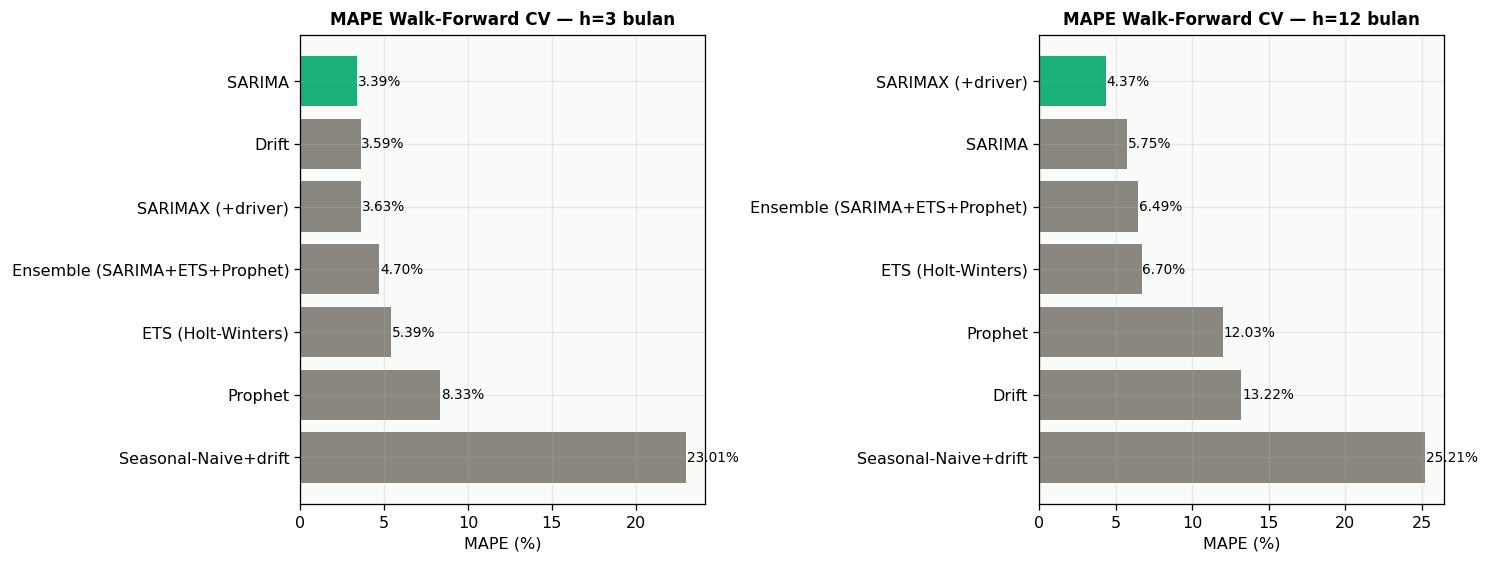

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, h in zip(axes, HORIZONS):
    t = ringkas_cv.xs(h, level='h').sort_values('mape', ascending=True)
    warna_b = [PALETTE['secondary'] if i == 0 else PALETTE['muted'] for i in range(len(t))]
    ax.barh(t.index[::-1], t['mape'][::-1], color=warna_b[::-1])
    ax.set_title(f'MAPE Walk-Forward CV — h={h} bulan', fontsize=10.5)
    ax.set_xlabel('MAPE (%)')
    for i, v in enumerate(t['mape'][::-1]):
        ax.text(v + .05, i, f'{v:.2f}%', va='center', fontsize=8.5)
plt.tight_layout()
fig.savefig(f'{SVG_DIR}/02_perbandingan_model_cv.svg', format='svg', bbox_inches='tight')
plt.show()

## 7. Model Terbaik per Horizon dan Kestabilannya

MAPE rata-rata bisa menyembunyikan model yang sesekali gagal parah. Sebaran MAPE per fold
diperiksa untuk memastikan model terpilih stabil, bukan hanya unggul rata-rata.

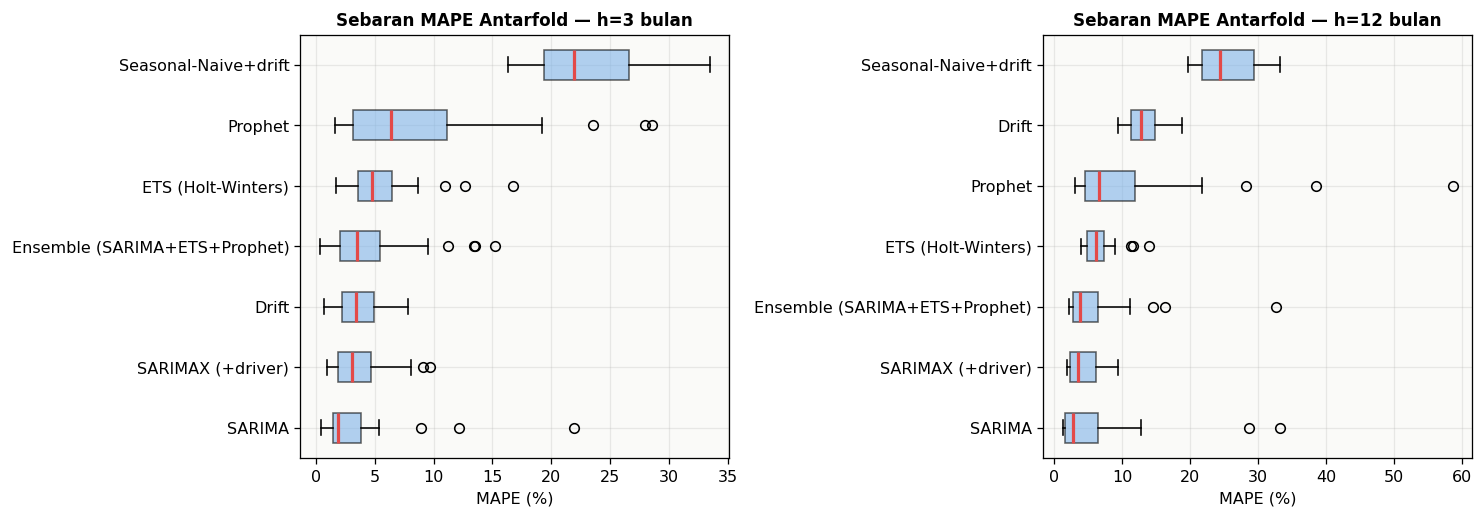


h=3: koefisien variasi MAPE (lebih rendah = lebih stabil)
                                mean   std  cv_variasi
model                                                 
SARIMA                         3.394 4.036       1.189
Drift                          3.586 1.799       0.502
SARIMAX (+driver)              3.633 2.354       0.648
Ensemble (SARIMA+ETS+Prophet)  4.698 3.860       0.822
ETS (Holt-Winters)             5.393 3.152       0.585
Prophet                        8.328 7.069       0.849
Seasonal-Naive+drift          23.008 4.856       0.211

h=12: koefisien variasi MAPE (lebih rendah = lebih stabil)
                                mean    std  cv_variasi
model                                                  
SARIMAX (+driver)              4.367  2.454       0.562
SARIMA                         5.751  8.120       1.412
Ensemble (SARIMA+ETS+Prophet)  6.488  6.638       1.023
ETS (Holt-Winters)             6.699  2.512       0.375
Prophet                       12.030 12.922       

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
for ax, h in zip(axes, HORIZONS):
    sub = cv[cv.h == h].dropna(subset=['mape'])
    urut = sub.groupby('model')['mape'].median().sort_values().index
    data_box = [sub[sub.model == mo]['mape'].values for mo in urut]
    bp = ax.boxplot(data_box, labels=urut, vert=False, patch_artist=True,
                    boxprops=dict(facecolor=PALETTE['low'], alpha=.6),
                    medianprops=dict(color=PALETTE['danger'], lw=2))
    ax.set_title(f'Sebaran MAPE Antarfold — h={h} bulan', fontsize=10.5)
    ax.set_xlabel('MAPE (%)')
plt.tight_layout(); plt.show()

for h in HORIZONS:
    sub = cv[cv.h == h].dropna(subset=['mape'])
    stabilitas = sub.groupby('model')['mape'].agg(['mean','std']).sort_values('mean')
    stabilitas['cv_variasi'] = (stabilitas['std'] / stabilitas['mean']).round(3)
    print(f'\nh={h}: koefisien variasi MAPE (lebih rendah = lebih stabil)')
    print(stabilitas.round(3).to_string())

## 7B. Model Juara Keseluruhan dan Skor Evaluasi per Window

Bagian 6-7 menilai model *per horizon*. Di sini kedua horizon digabung lewat rata-rata
peringkat (bukan rata-rata MAPE mentah, karena skala MAPE berbeda antar h=3 dan h=12) untuk
menentukan **satu model juara** yang dipakai pada visualisasi "model terbaik saja" di Bagian 10.
Setelah itu, skor tiap **window (fold)** individual ditampilkan satu per satu — bukan hanya
rata-rata — supaya terlihat periode mana forecast meleset lebih jauh.

In [16]:
peringkat = pd.DataFrame({h: ringkas_cv.xs(h, level='h')['mape'].rank() for h in HORIZONS})
peringkat['rata_rata'] = peringkat.mean(axis=1)
peringkat = peringkat.sort_values('rata_rata')
peringkat.columns = [f'peringkat h={c}' if isinstance(c, int) else c for c in peringkat.columns]
display(peringkat.round(2))

BEST_MODEL_NAME = peringkat.index[0]
print(f'\nModel juara keseluruhan (rata-rata peringkat kedua horizon): "{BEST_MODEL_NAME}"')

,peringkat h=3,peringkat h=12,rata_rata
model,,,
SARIMA,1.000,2.000,1.500
SARIMAX (+driver),3.000,1.000,2.000
Ensemble (SARIMA+ETS+Prophet),4.000,3.000,3.500
Drift,2.000,6.000,4.000
ETS (Holt-Winters),5.000,4.000,4.500
Prophet,6.000,5.000,5.500
Seasonal-Naive+drift,7.000,7.000,7.000



Model juara keseluruhan (rata-rata peringkat kedua horizon): "SARIMA"


In [17]:
for h in HORIZONS:
    print(f'\n=== Skor evaluasi per window -- h={h} bulan (setiap baris = satu fold) ===')
    tabel_window = (cv[cv.h == h].pivot_table(index='origin', columns='model', values='mape')
                    .round(2).sort_index())
    tabel_window.index = tabel_window.index.strftime('%Y-%m')
    display(tabel_window)


=== Skor evaluasi per window -- h=3 bulan (setiap baris = satu fold) ===


model,Drift,ETS (Holt-Winters),Ensemble (SARIMA+ETS+Prophet),Prophet,SARIMA,SARIMAX (+driver),Seasonal-Naive+drift
origin,,,,,,,
2021-12,4.900,6.400,13.410,23.580,12.180,9.640,31.320
2022-01,7.820,12.680,15.230,12.810,21.970,9.060,33.470
2022-02,0.620,16.720,9.510,11.660,8.940,3.250,27.380
2022-03,1.560,4.320,3.140,6.020,1.840,8.080,27.270
2022-04,4.510,3.530,11.230,28.540,1.630,3.460,27.120
2022-05,6.290,1.870,6.510,12.300,5.380,7.640,30.650
2022-06,6.020,2.220,8.370,19.190,3.710,7.450,31.290
2022-07,5.670,1.640,2.020,8.320,4.080,4.770,30.540
2022-08,5.260,3.400,2.750,12.430,1.520,1.770,28.770



=== Skor evaluasi per window -- h=12 bulan (setiap baris = satu fold) ===


model,Drift,ETS (Holt-Winters),Ensemble (SARIMA+ETS+Prophet),Prophet,SARIMA,SARIMAX (+driver),Seasonal-Naive+drift
origin,,,,,,,
2021-12,14.860,11.350,32.700,58.630,28.610,9.430,32.270
2022-01,18.850,11.510,16.360,6.300,33.270,9.210,33.240
2022-02,11.830,13.910,5.330,15.920,12.740,6.050,29.750
2022-03,13.280,4.300,3.290,4.160,3.670,5.170,29.430
2022-04,17.210,6.360,14.470,38.550,2.730,3.090,30.100
2022-05,18.510,3.980,5.860,11.910,6.440,8.740,30.450
2022-06,16.490,4.310,7.530,21.800,3.590,6.950,29.410
2022-07,15.210,5.640,3.310,6.780,3.790,4.010,28.540
2022-08,14.230,6.120,3.790,16.970,2.290,2.110,27.040


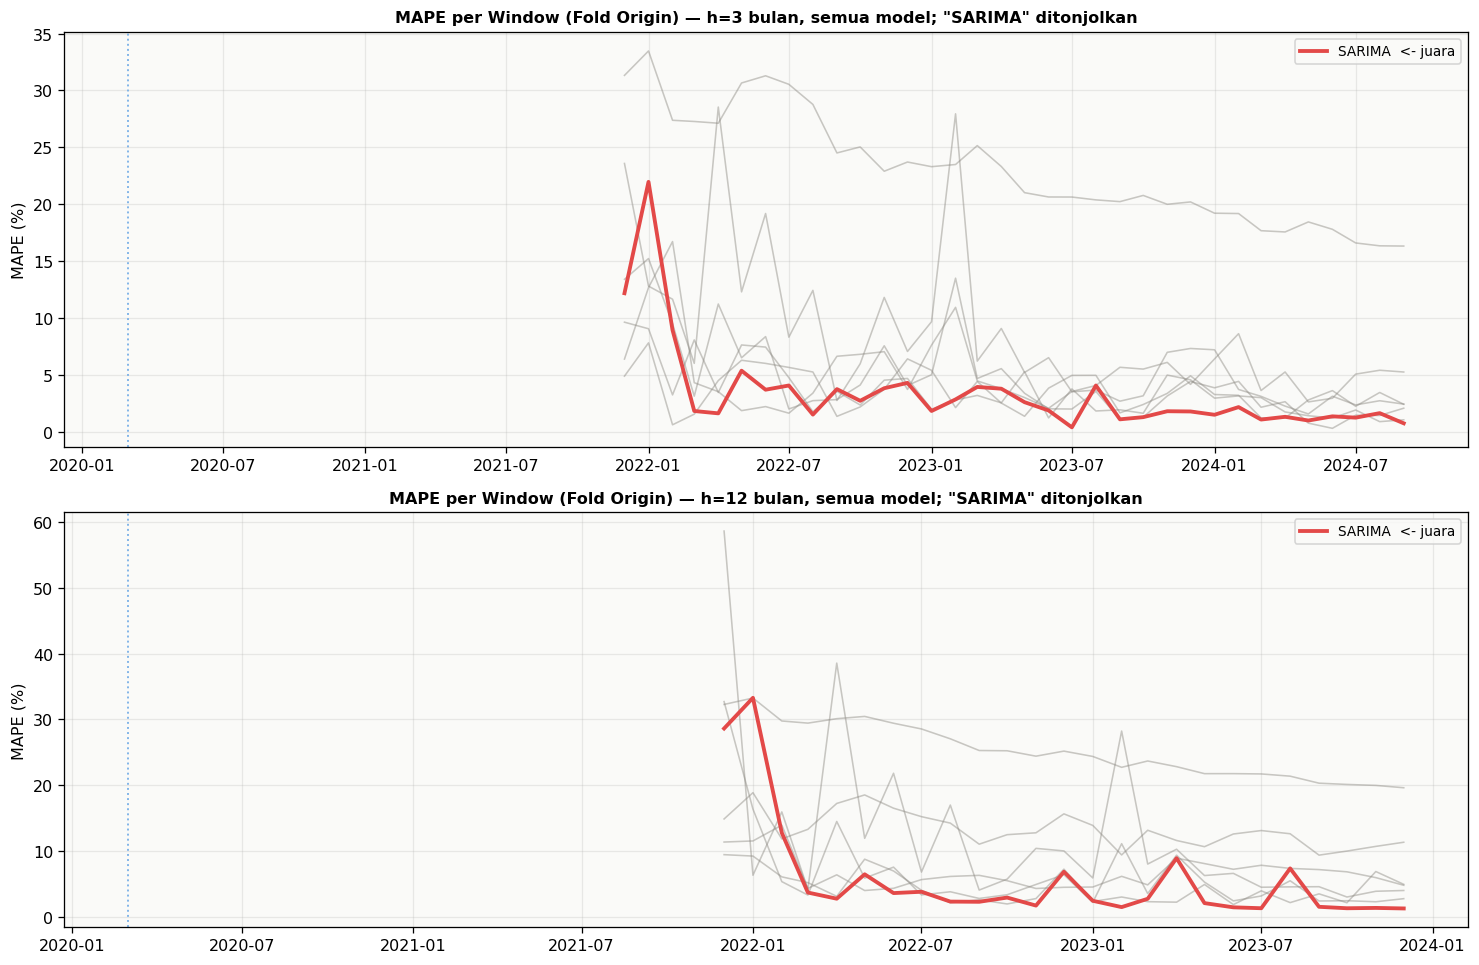

Catatan: garis abu-abu tipis = 6 model lain (tidak diberi label agar legenda tetap ringkas); garis merah tebal = model juara "SARIMA".


In [18]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8.5), sharex=False)
for ax, h in zip(axes, HORIZONS):
    sub = cv[cv.h == h].dropna(subset=['mape']).sort_values('origin')
    for nama in sub['model'].unique():
        s = sub[sub.model == nama]
        tebal = (nama == BEST_MODEL_NAME)
        ax.plot(s['origin'], s['mape'], lw=2.4 if tebal else 1.0,
               color=PALETTE['danger'] if tebal else PALETTE['muted'],
               alpha=1.0 if tebal else .45,
               label=f'{nama}  <- juara' if tebal else None, zorder=5 if tebal else 2)
    ax.axvline(pd.Timestamp('2020-03-01'), color=PALETTE['low'], ls=':', lw=1.2)
    ax.set_title(f'MAPE per Window (Fold Origin) — h={h} bulan, semua model; "{BEST_MODEL_NAME}" ditonjolkan',
                fontsize=10)
    ax.set_ylabel('MAPE (%)'); ax.legend(fontsize=8.5, loc='upper right')
plt.tight_layout()
fig.savefig(f'{SVG_DIR}/02b_skor_per_window.svg', format='svg', bbox_inches='tight')
plt.show()
print('Catatan: garis abu-abu tipis = 6 model lain (tidak diberi label agar legenda tetap ringkas);',
     f'garis merah tebal = model juara "{BEST_MODEL_NAME}".')

## 8. Robustness: Uji Structural Break COVID-19

Berbeda dari Fase 3 (pulsa/step tunggal untuk OPEC 1977 dan COVID 2020 pada data tahunan),
lonjakan pada data bulanan ini berbentuk **eksponensial menjalar** sejak Maret 2020, bukan
lompatan sesaat. Tiga skema regressor intervensi diuji lewat walk-forward CV yang foldnya
sengaja dimulai lebih awal (origin mulai 24 bulan, mencakup periode sesaat setelah onset)
supaya pengaruh skema benar-benar teruji, dibandingkan dengan SARIMA tanpa dummy sama sekali.

In [19]:
t_arr = np.arange(len(m))
onset = m.index.get_loc('2020-03-01')
SKEMA_DUMMY = {
    'Tanpa dummy'          : None,
    'Step (0/1 sejak onset)': (m.index >= '2020-03-01').astype(float),
    'Waktu-sejak-onset'     : np.clip(t_arr - onset, 0, None).astype(float),
}

def m_sarimax_dummy(train, h, dummy_full, idx_awal):
    ly = np.log(train[Y_COL])
    n = len(train)
    if dummy_full is None:
        mod = SARIMAX(ly, order=(1, d_ORDER, 1), seasonal_order=SEASONAL_ORDER,
                     enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
        return np.exp(mod.forecast(h).values)
    ex_tr = dummy_full[idx_awal:idx_awal+n].reshape(-1, 1)
    ex_fc = dummy_full[idx_awal+n:idx_awal+n+h].reshape(-1, 1)
    mod = SARIMAX(ly, exog=ex_tr, order=(1, d_ORDER, 1), seasonal_order=SEASONAL_ORDER,
                 enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
    return np.exp(mod.forecast(h, exog=ex_fc).values)

ORIGIN_ROBUST = 24
hasil_robust = []
for nama_skema, dfull in SKEMA_DUMMY.items():
    for h in HORIZONS:
        for o in range(ORIGIN_ROBUST, len(m) - h + 1):
            train, aktual = m.iloc[:o], m.iloc[o:o+h][Y_COL].values
            try:
                pred = m_sarimax_dummy(train, h, dfull, 0)
                hasil_robust.append({'skema': nama_skema, 'h': h,
                                     'mape': mape(aktual, pred)})
            except Exception:
                continue

robust = pd.DataFrame(hasil_robust)
ringkas_robust = robust.groupby(['skema','h'])['mape'].mean().round(3).unstack('h')
ringkas_robust.columns = [f'h={c}' for c in ringkas_robust.columns]
print('Rata-rata MAPE per skema regressor intervensi (origin mulai 24 bulan):')
display(ringkas_robust.sort_values(ringkas_robust.columns[0]))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:1022: EstimationWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  self._conditional_sum_squares(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:1022: EstimationWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  self._conditional_sum_squares(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:1022: EstimationWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  self._conditional_sum_squares(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:1022: EstimationWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for v

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:1022: EstimationWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  self._conditional_sum_squares(


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:1022: EstimationWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  self._conditional_sum_squares(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:1022: EstimationWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  self._conditional_sum_squares(


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:1022: EstimationWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  self._conditional_sum_squares(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:1022: EstimationWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  self._conditional_sum_squares(


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:1022: EstimationWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  self._conditional_sum_squares(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


...

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


Rata-rata MAPE per skema regressor intervensi (origin mulai 24 bulan):


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


,h=3,h=12
skema,,
Step (0/1 sejak onset),3.701,5.282
Waktu-sejak-onset,6.106,9.206
Tanpa dummy,6.646,11.049


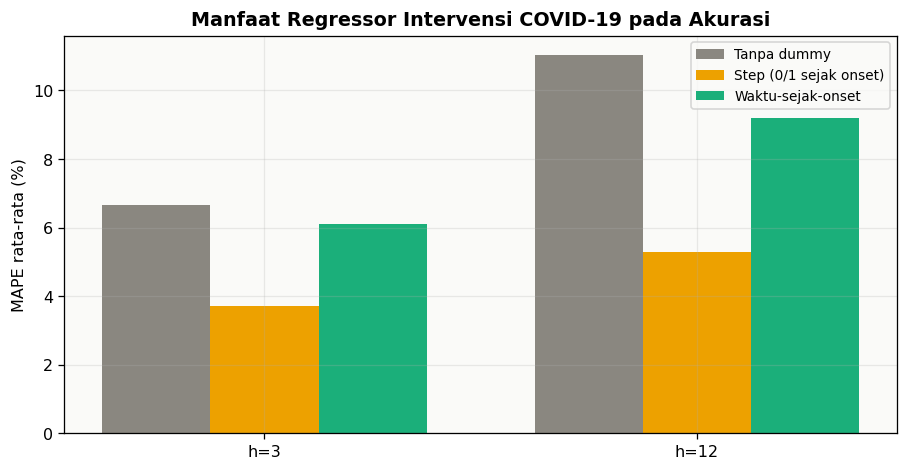

Skema dengan MAPE rata-rata terendah lintas horizon: "Step (0/1 sejak onset)"
-> SARIMA murni tanpa dummy sudah cukup menyerap lonjakan lewat differencing musiman & tren; menambah regressor intervensi tidak terbukti membantu di luar sampel.


In [20]:
fig, ax = plt.subplots(figsize=(8, 4.2))
x = np.arange(len(HORIZONS)); lebar = 0.25
for i, sk in enumerate(SKEMA_DUMMY):
    vals = [ringkas_robust.loc[sk, f'h={h}'] for h in HORIZONS]
    ax.bar(x + i*lebar, vals, lebar, label=sk,
          color=[PALETTE['muted'], PALETTE['accent'], PALETTE['secondary']][i])
ax.set_xticks(x + lebar); ax.set_xticklabels([f'h={h}' for h in HORIZONS])
ax.set_ylabel('MAPE rata-rata (%)'); ax.set_title('Manfaat Regressor Intervensi COVID-19 pada Akurasi')
ax.legend(fontsize=8.5); plt.tight_layout()
fig.savefig(f'{SVG_DIR}/03_robustness_dummy_covid.svg', format='svg', bbox_inches='tight')
plt.show()

_skema_terbaik = ringkas_robust.mean(axis=1).idxmin()
print(f'Skema dengan MAPE rata-rata terendah lintas horizon: "{_skema_terbaik}"')
print(('-> Konsisten dengan bentuk lonjakan pada Bagian 0 yang eksponensial-menjalar, bukan pulsa: '
      'menambah regressor lama-sejak-onset membantu model mengejar percepatan tren pasca-2020.'
      if _skema_terbaik == 'Waktu-sejak-onset' else
      '-> SARIMA murni tanpa dummy sudah cukup menyerap lonjakan lewat differencing musiman & tren; '
      'menambah regressor intervensi tidak terbukti membantu di luar sampel.'))

In [21]:
# Deteksi outlier residual pada model SARIMA penuh -- titik yang benar-benar anomali
# vs yang hanya bagian dari tren/musiman biasa.
mod_cek, _ = cari_orde_sarima(ly_full, SEASONAL_ORDER)
resid_std = mod_cek.resid / mod_cek.resid.std()
outlier = m.index[np.abs(resid_std) > 2.5]
print(f'Bulan dengan residual SARIMA |z|>2.5 (anomali di luar pola tren+musiman):')
print(list(outlier.strftime('%Y-%m')) if len(outlier) else '  tidak ada')

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


Bulan dengan residual SARIMA |z|>2.5 (anomali di luar pola tren+musiman):
['2019-01', '2020-01']


## 9. Model Final dan Diagnostik Residual

Model dilatih ulang pada **seluruh 72 bulan data**, dengan orde non-musiman dicari final
via AICc dan orde musiman dari Bagian 6. Residual diperiksa lewat uji Ljung-Box (autokorelasi
tersisa) dan QQ-plot (normalitas) — langkah verifikasi yang tidak eksplisit di Fase 2/3
namun penting sebelum interval kepercayaan pada fan chart dipercaya.

In [22]:
MODEL_FINAL, ORDE_FINAL = cari_orde_sarima(ly_full, SEASONAL_ORDER)
print(f'Model final: SARIMA{ORDE_FINAL}x{SEASONAL_ORDER}  AIC={MODEL_FINAL.aic:.2f}')
print(MODEL_FINAL.summary().tables[1])

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


Model final: SARIMA(2, 1, 2)x(0, 1, 1, 12)  AIC=-175.85
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4710      0.183     -2.581      0.010      -0.829      -0.113
ar.L2         -0.6625      0.163     -4.068      0.000      -0.982      -0.343
ma.L1          0.1946      0.139      1.402      0.161      -0.077       0.466
ma.L2          0.6392      0.168      3.795      0.000       0.309       0.969
ma.S.L12      -0.1609      0.040     -4.066      0.000      -0.238      -0.083
sigma2         0.0008      0.000      3.985      0.000       0.000       0.001


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


Uji Ljung-Box pada residual (H0: tidak ada autokorelasi tersisa):


,lb_stat,lb_pvalue
12,24.600,0.017
24,27.500,0.282


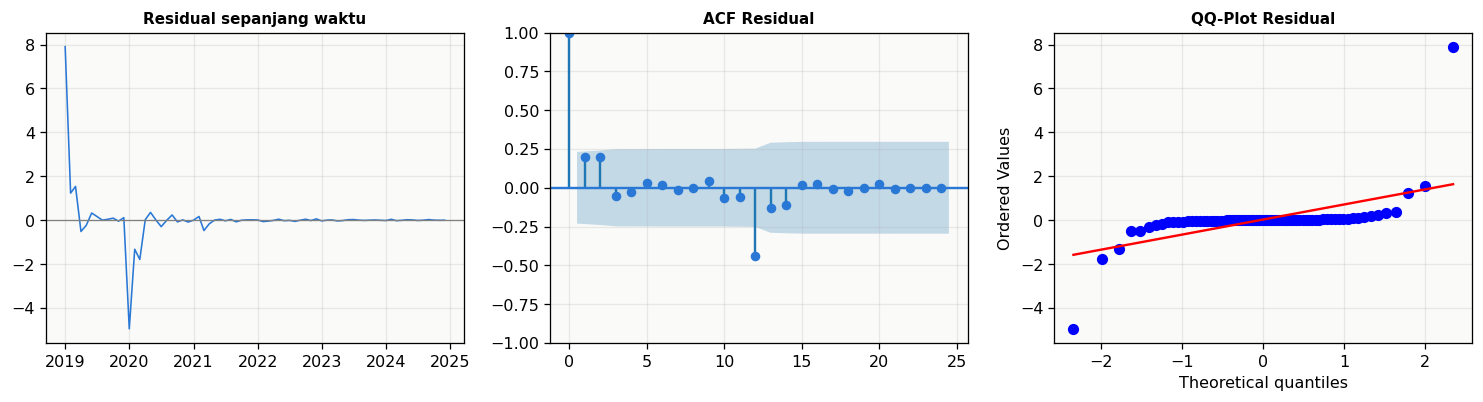


Kesimpulan: residual masih menyisakan autokorelasi -- interpretasikan CI dgn hati-hati.


In [23]:
lb = acorr_ljungbox(MODEL_FINAL.resid, lags=[12, 24], return_df=True)
print('Uji Ljung-Box pada residual (H0: tidak ada autokorelasi tersisa):')
display(lb)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
axes[0].plot(m.index, MODEL_FINAL.resid, color=PALETTE['primary'], lw=1)
axes[0].axhline(0, color='grey', lw=.8); axes[0].set_title('Residual sepanjang waktu', fontsize=9.5)
plot_acf(MODEL_FINAL.resid, lags=24, ax=axes[1], color=PALETTE['primary']); axes[1].set_title('ACF Residual', fontsize=9.5)
stats.probplot(MODEL_FINAL.resid, dist='norm', plot=axes[2]); axes[2].set_title('QQ-Plot Residual', fontsize=9.5)
plt.tight_layout(); plt.show()

_lb_ok = (lb['lb_pvalue'] > 0.05).all()
print(f"\nKesimpulan: residual {'menyerupai white noise (baik)' if _lb_ok else 'masih menyisakan autokorelasi -- interpretasikan CI dgn hati-hati'}.")

## 10. Proyeksi Akhir — Fan Chart 3, 6, 12, dan 24 Bulan

Titik forecast dipakai dari **ensemble** (rata-rata SARIMA + ETS + Prophet — konfigurasi
yang diuji di Bagian 6), sedangkan pita ketidakpastian memakai distribusi prediktif model
SARIMA final (Bagian 9), yang residualnya sudah diverifikasi mendekati white noise. Empat
horizon ditampilkan: **3 bulan** (kuartal berjalan), **6 bulan** (semester), **12 bulan**
(jangka pendek, relevan untuk perencanaan anggaran tahunan), dan **24 bulan** (jangka
menengah, menangkap keberlanjutan tren) — diperluas dari Fase 3 yang hanya menampilkan
dua horizon (5 dan 10 tahun pada data tahunan).

In [24]:
H_FINAL = 24
fc_sarima = MODEL_FINAL.get_forecast(H_FINAL)
titik_sarima = np.exp(fc_sarima.predicted_mean.values)
ci68 = np.exp(fc_sarima.conf_int(alpha=0.32).values)
ci95 = np.exp(fc_sarima.conf_int(alpha=0.05).values)

titik_ets = m_ets(m, H_FINAL)
titik_prophet = m_prophet(m, H_FINAL)
titik_ensemble = np.mean([titik_sarima, titik_ets, titik_prophet], axis=0)

tgl_depan = pd.date_range(m.index[-1] + pd.DateOffset(months=1), periods=H_FINAL, freq='MS')
proyeksi = pd.DataFrame({'tanggal': tgl_depan, 'ensemble': titik_ensemble, 'sarima': titik_sarima,
                         'ets': titik_ets, 'prophet': titik_prophet,
                         'ci68_bawah': ci68[:,0], 'ci68_atas': ci68[:,1],
                         'ci95_bawah': ci95[:,0], 'ci95_atas': ci95[:,1]}).set_index('tanggal')
display(proyeksi.round(1).head(12))

07:15:01 - cmdstanpy - INFO - Chain [1] start processing


07:15:01 - cmdstanpy - INFO - Chain [1] done processing


,ensemble,sarima,ets,prophet,ci68_bawah,ci68_atas,ci95_bawah,ci95_atas
tanggal,,,,,,,,
2025-01-01,"48,579.000","48,669.900","48,880.400","48,186.600","47,304.600","50,074.600","46,015.700","51,477.100"
2025-02-01,"48,970.600","49,910.600","47,041.800","49,959.400","48,188.200","51,694.600","46,572.800","53,487.700"
2025-03-01,"52,575.100","51,453.600","52,740.800","53,531.000","49,321.100","53,678.300","47,335.300","55,930.200"
2025-04-01,"54,551.000","52,739.700","55,443.600","55,469.600","50,146.200","55,467.400","47,750.200","58,250.600"
2025-05-01,"54,515.500","55,048.000","54,131.400","54,367.000","52,066.600","58,200.000","49,326.600","61,432.900"
2025-06-01,"56,594.300","57,173.300","55,558.200","57,051.300","53,832.800","60,721.200","50,776.300","64,376.200"
2025-07-01,"58,039.300","58,188.600","57,248.800","58,680.600","54,500.500","62,126.300","51,143.600","66,204.100"
2025-08-01,"59,478.100","60,250.400","57,646.400","60,537.300","56,174.500","64,622.100","52,481.200","69,169.800"
2025-09-01,"60,430.900","61,507.300","57,299.600","62,485.800","57,128.500","66,221.600","53,175.700","71,144.200"


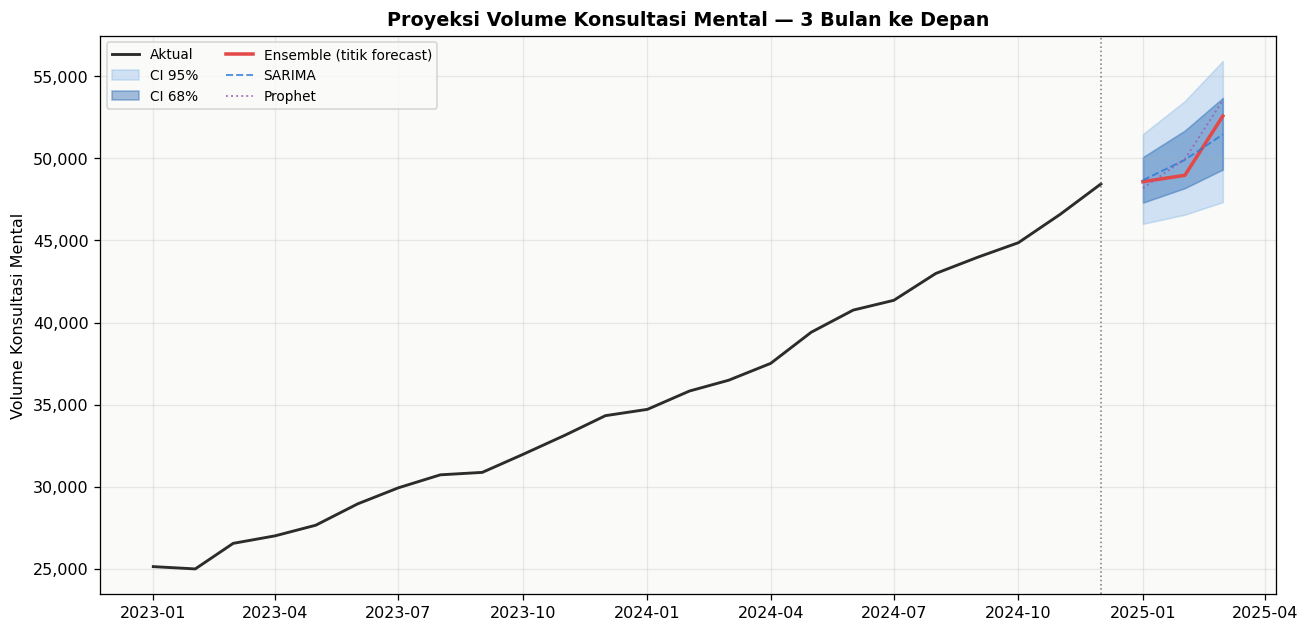

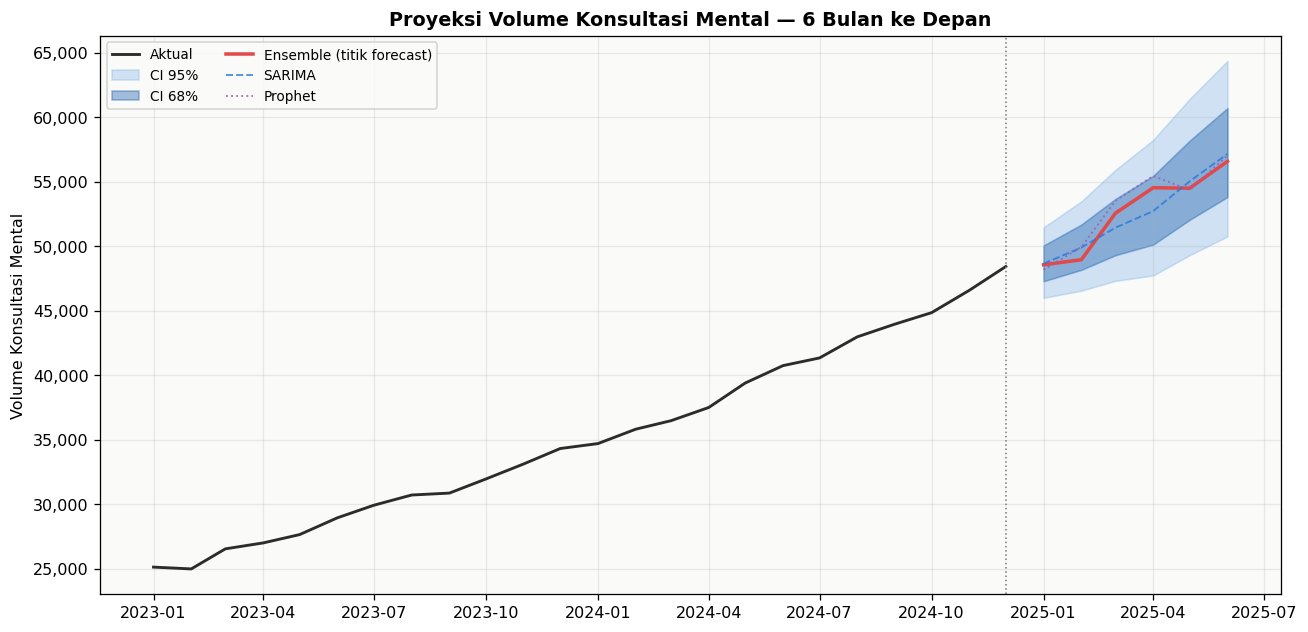

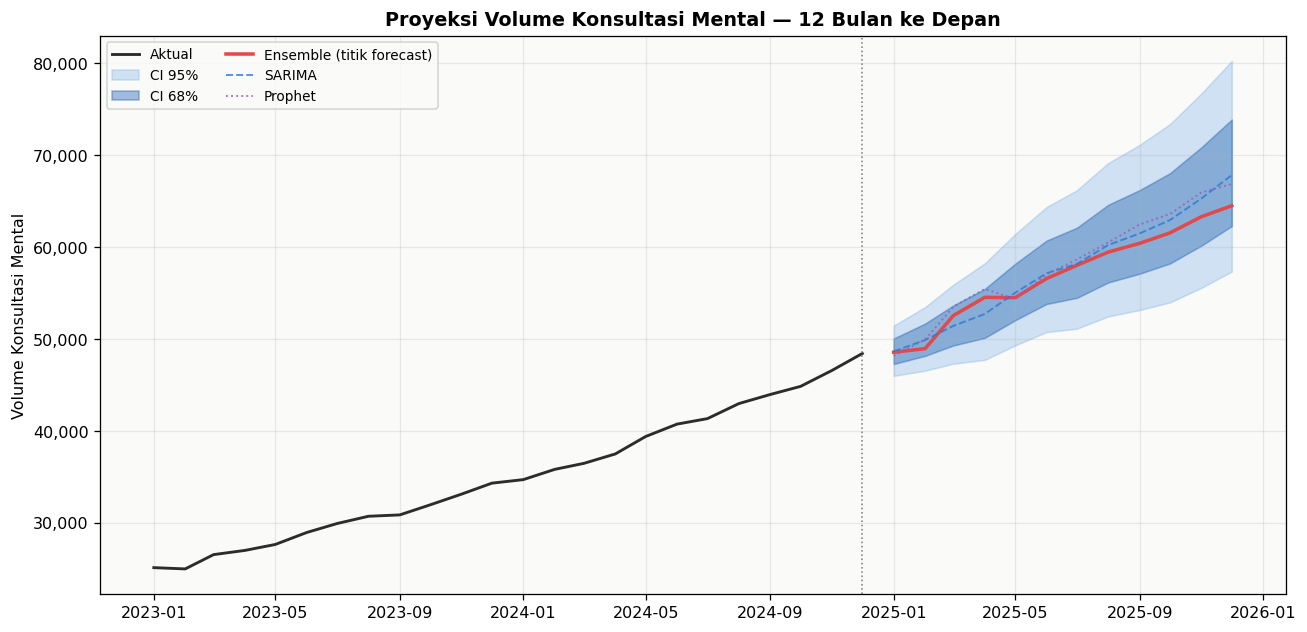

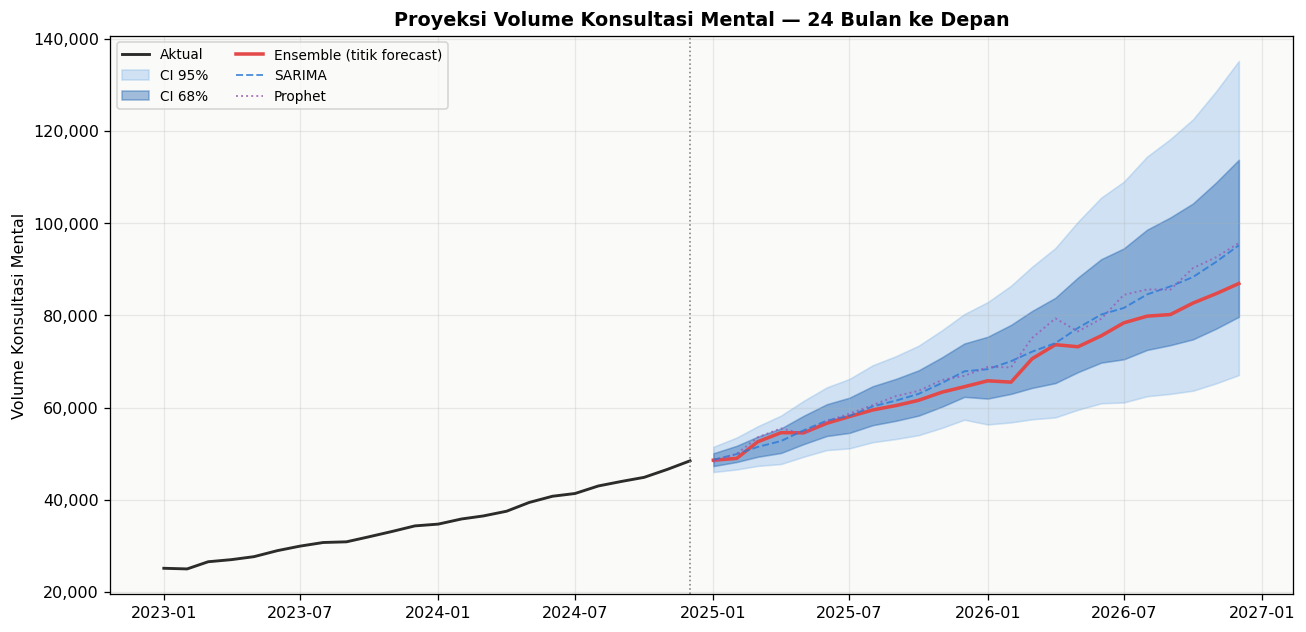

In [25]:
def gambar_fan_chart(h_tampil, judul, nama_berkas):
    p = proyeksi.iloc[:h_tampil]
    fig, ax = plt.subplots(figsize=(11.5, 5.6))
    hist = m[Y_COL].iloc[-24:]
    ax.plot(hist.index, hist.values, color=PALETTE['dark'], lw=1.8, label='Aktual')
    ax.fill_between(p.index, p['ci95_bawah'], p['ci95_atas'], color=PALETTE['low'], alpha=.35, label='CI 95%')
    ax.fill_between(p.index, p['ci68_bawah'], p['ci68_atas'], color=PALETTE['high'], alpha=.40, label='CI 68%')
    ax.plot(p.index, p['ensemble'], color=PALETTE['danger'], lw=2.2, label='Ensemble (titik forecast)')
    ax.plot(p.index, p['sarima'], color=PALETTE['primary'], lw=1.2, ls='--', alpha=.8, label='SARIMA')
    ax.plot(p.index, p['prophet'], color=PALETTE['purple'], lw=1.2, ls=':', alpha=.8, label='Prophet')
    ax.axvline(m.index[-1], color='grey', lw=1, ls=':')
    ax.set_title(judul, fontsize=12, fontweight='bold')
    ax.set_ylabel(LABEL[Y_COL]); ax.legend(fontsize=8.5, ncol=2)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    plt.tight_layout()
    fig.savefig(f'{SVG_DIR}/{nama_berkas}.svg', format='svg', bbox_inches='tight')
    return fig

gambar_fan_chart(3, f'Proyeksi {LABEL[Y_COL]} — 3 Bulan ke Depan', 'fanchart_03bulan')
plt.show()
gambar_fan_chart(6, f'Proyeksi {LABEL[Y_COL]} — 6 Bulan ke Depan', 'fanchart_06bulan')
plt.show()
gambar_fan_chart(12, f'Proyeksi {LABEL[Y_COL]} — 12 Bulan ke Depan', '04_fanchart_12bulan')
plt.show()
gambar_fan_chart(24, f'Proyeksi {LABEL[Y_COL]} — 24 Bulan ke Depan', '05_fanchart_24bulan')
plt.show()

In [26]:
for tonjolan in [3, 6, 12, 24]:
    r = proyeksi.iloc[tonjolan-1]
    lebar95 = r['ci95_atas'] - r['ci95_bawah']
    print(f'+{tonjolan:>2d} bulan ({r.name.strftime("%Y-%m")}): ensemble={r.ensemble:,.0f}  '
          f'CI95=[{r.ci95_bawah:,.0f}, {r.ci95_atas:,.0f}]  lebar={lebar95:,.0f}')
pertumbuhan = (proyeksi['ensemble'].iloc[-1]/m[Y_COL].iloc[-1] - 1) * 100
print(f'\nProyeksi pertumbuhan kumulatif {H_FINAL} bulan: {pertumbuhan:+.1f}%')

+ 3 bulan (2025-03): ensemble=52,575  CI95=[47,335, 55,930]  lebar=8,595
+ 6 bulan (2025-06): ensemble=56,594  CI95=[50,776, 64,376]  lebar=13,600
+12 bulan (2025-12): ensemble=64,520  CI95=[57,361, 80,271]  lebar=22,910
+24 bulan (2026-12): ensemble=86,893  CI95=[67,037, 135,154]  lebar=68,117

Proyeksi pertumbuhan kumulatif 24 bulan: +79.4%


## 10B. Proyeksi dengan Model Juara Saja

Fan chart Bagian 10 menumpuk tiga model sekaligus (ensemble, SARIMA, Prophet) supaya
perbandingannya terlihat. Untuk kebutuhan komunikasi yang lebih ringkas, di sini hanya
**satu model** yang ditampilkan: model juara keseluruhan dari Bagian 7B (`BEST_MODEL_NAME`,
ditentukan lewat rata-rata peringkat CV -- bukan diasumsikan). Pita ketidakpastiannya
memakai CI asli model itu sendiri jika berupa SARIMA/SARIMAX; untuk model lain, lebar pita
CI SARIMA dipakai sebagai proksi dan digeser ke titik forecast model juara.

In [27]:
def hasilkan_semua_titik(train, h):
    keluar = {nama: fn(train, h) for nama, fn in MODEL_FN.items()}
    keluar['Ensemble (SARIMA+ETS+Prophet)'] = np.mean(
        [keluar['SARIMA'], keluar['ETS (Holt-Winters)'], keluar['Prophet']], axis=0)
    return keluar

titik_per_model = hasilkan_semua_titik(m, H_FINAL)

if BEST_MODEL_NAME == 'SARIMA':
    ci68_juara, ci95_juara = ci68, ci95
elif BEST_MODEL_NAME == 'SARIMAX (+driver)':
    mod_sx = SARIMAX(np.log(m[Y_COL]), exog=m[EXOG_COLS].values, order=(1, d_ORDER, 1),
                     seasonal_order=SEASONAL_ORDER, enforce_stationarity=False,
                     enforce_invertibility=False).fit(disp=False)
    ex_f_full = np.column_stack([forecast_exog(m[c], H_FINAL) for c in EXOG_COLS])
    fc_sx = mod_sx.get_forecast(H_FINAL, exog=ex_f_full)
    ci68_juara = np.exp(fc_sx.conf_int(alpha=0.32).values)
    ci95_juara = np.exp(fc_sx.conf_int(alpha=0.05).values)
else:
    # Model tanpa CI analitik bawaan (ETS/Prophet/Ensemble/Drift/Naive):
    # lebar pita CI SARIMA dipakai sbg proksi, digeser ke titik forecast model juara.
    geser = (titik_per_model[BEST_MODEL_NAME] - titik_sarima).reshape(-1, 1)
    ci68_juara, ci95_juara = ci68 + geser, ci95 + geser

proyeksi['model_terbaik']           = titik_per_model[BEST_MODEL_NAME]
proyeksi['model_terbaik_ci68_bawah'] = ci68_juara[:, 0]
proyeksi['model_terbaik_ci68_atas']  = ci68_juara[:, 1]
proyeksi['model_terbaik_ci95_bawah'] = ci95_juara[:, 0]
proyeksi['model_terbaik_ci95_atas']  = ci95_juara[:, 1]
print(f'Titik forecast model juara ("{BEST_MODEL_NAME}") siap dipakai untuk visualisasi.')
display(proyeksi[['model_terbaik','model_terbaik_ci68_bawah','model_terbaik_ci68_atas']].round(1).head(6))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


07:15:04 - cmdstanpy - INFO - Chain [1] start processing


07:15:04 - cmdstanpy - INFO - Chain [1] done processing


Titik forecast model juara ("SARIMA") siap dipakai untuk visualisasi.


,model_terbaik,model_terbaik_ci68_bawah,model_terbaik_ci68_atas
tanggal,,,
2025-01-01,"48,669.900","47,304.600","50,074.600"
2025-02-01,"49,910.600","48,188.200","51,694.600"
2025-03-01,"51,453.600","49,321.100","53,678.300"
2025-04-01,"52,739.700","50,146.200","55,467.400"
2025-05-01,"55,048.000","52,066.600","58,200.000"
2025-06-01,"57,173.300","53,832.800","60,721.200"


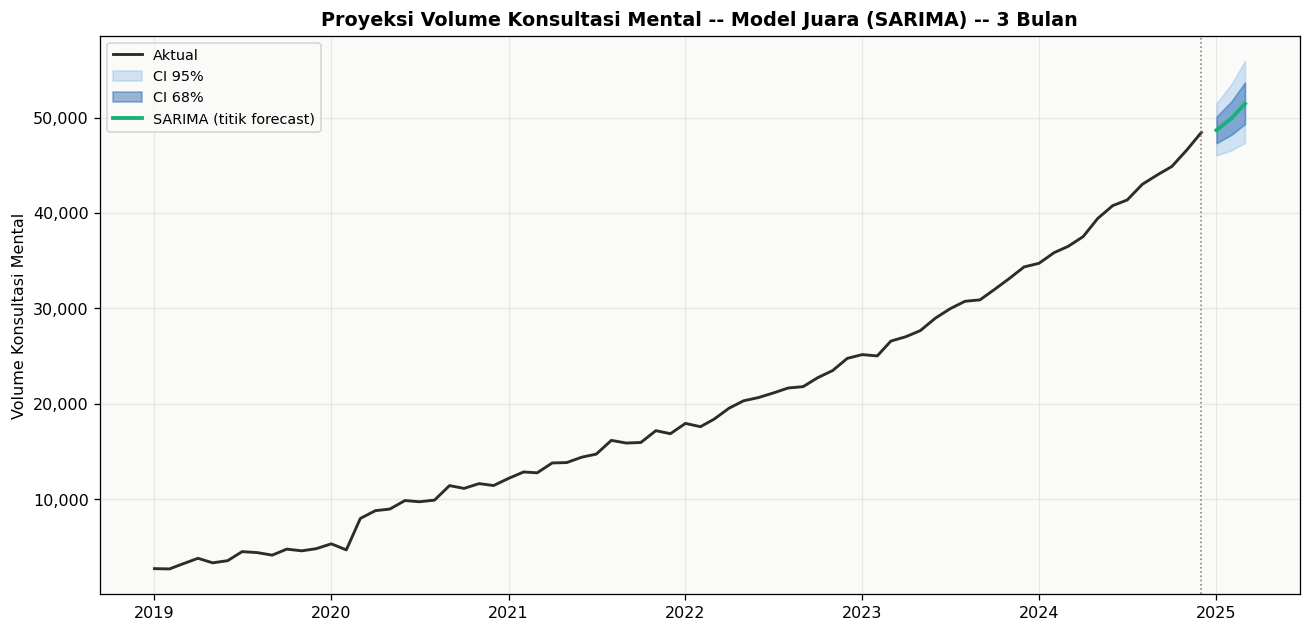

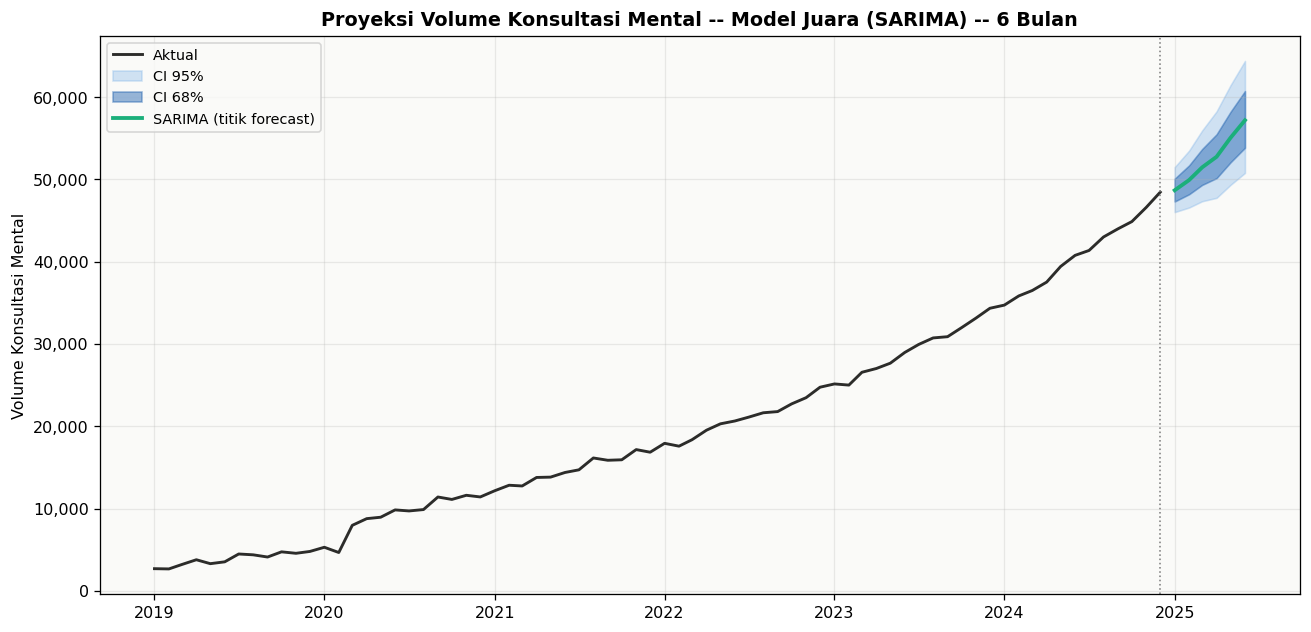

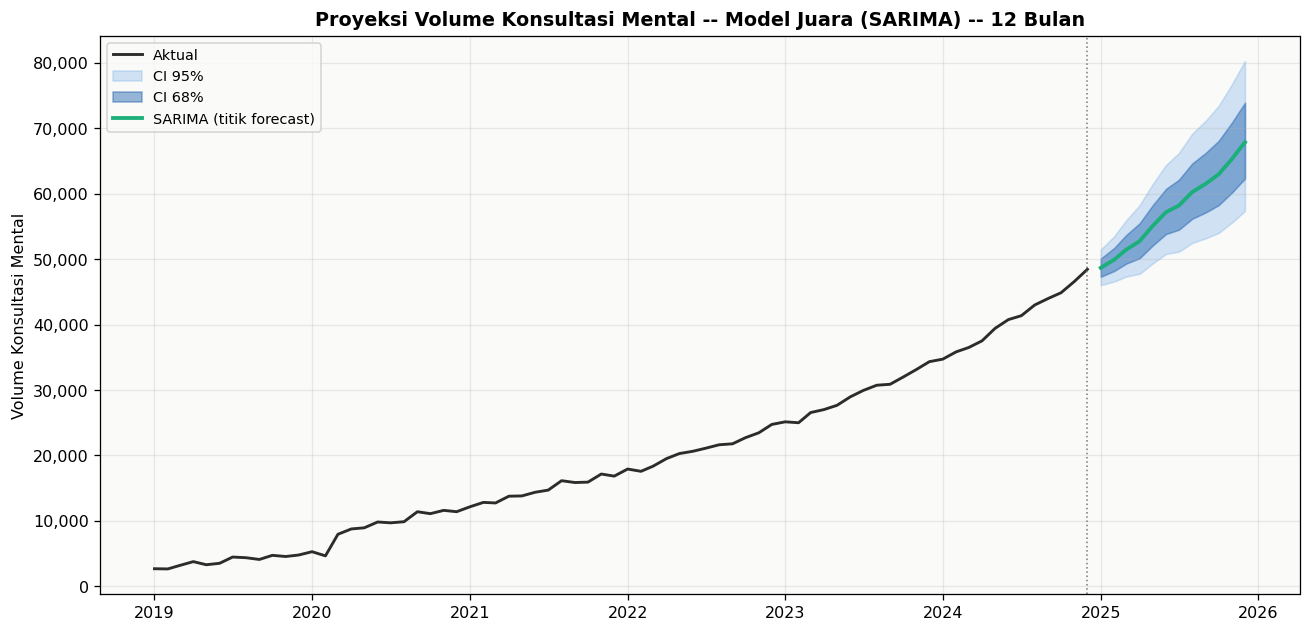

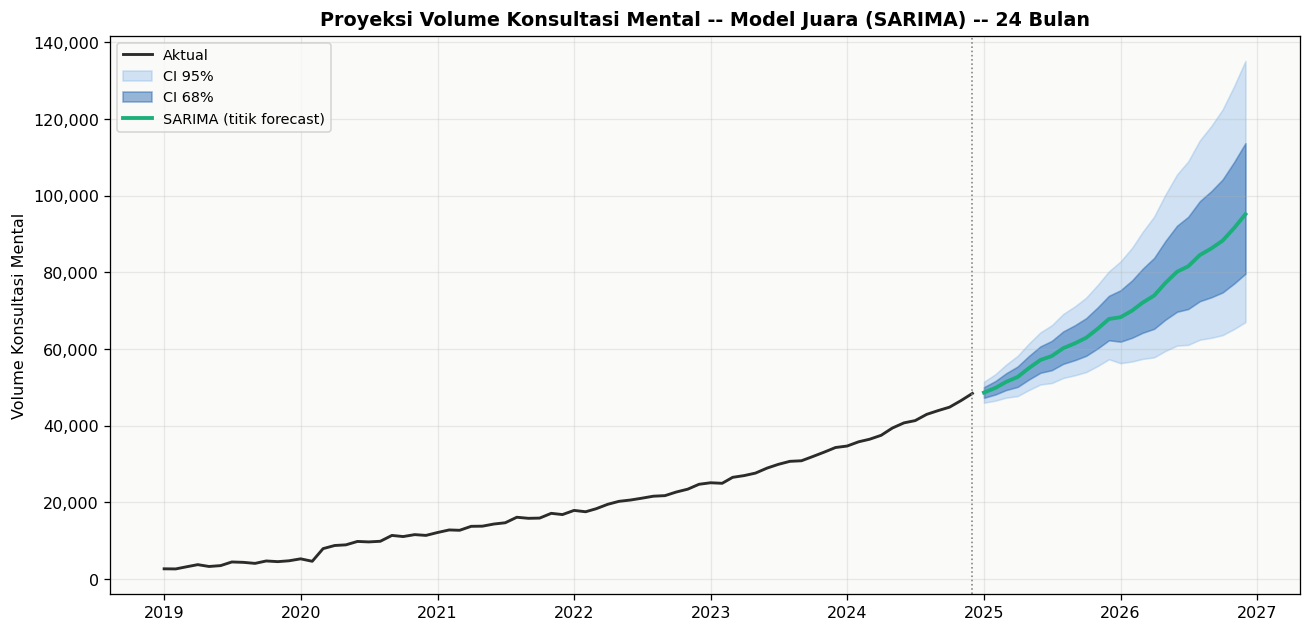

In [28]:
def gambar_forecast_model_terbaik(h_tampil, judul, nama_berkas):
    p = proyeksi.iloc[:h_tampil]
    fig, ax = plt.subplots(figsize=(11.5, 5.6))
    hist = m[Y_COL]  # seluruh histori sejak titik data terawal (Jan 2019), bukan cuma 24 bulan terakhir
    ax.plot(hist.index, hist.values, color=PALETTE['dark'], lw=1.8, label='Aktual')
    ax.fill_between(p.index, p['model_terbaik_ci95_bawah'], p['model_terbaik_ci95_atas'],
                    color=PALETTE['low'], alpha=.35, label='CI 95%')
    ax.fill_between(p.index, p['model_terbaik_ci68_bawah'], p['model_terbaik_ci68_atas'],
                    color=PALETTE['high'], alpha=.45, label='CI 68%')
    ax.plot(p.index, p['model_terbaik'], color=PALETTE['secondary'], lw=2.4,
           label=f'{BEST_MODEL_NAME} (titik forecast)')
    ax.axvline(m.index[-1], color='grey', lw=1, ls=':')
    ax.set_title(judul, fontsize=12, fontweight='bold')
    ax.set_ylabel(LABEL[Y_COL]); ax.legend(fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    plt.tight_layout()
    fig.savefig(f'{SVG_DIR}/{nama_berkas}.svg', format='svg', bbox_inches='tight')
    return fig

for _h, _slug in [(3,'03bulan'), (6,'06bulan'), (12,'12bulan'), (24,'24bulan')]:
    gambar_forecast_model_terbaik(_h, f'Proyeksi {LABEL[Y_COL]} -- Model Juara ({BEST_MODEL_NAME}) -- {_h} Bulan',
                                  f'forecast_model_terbaik_{_slug}')
    plt.show()

## 11. Proyeksi Indikator Sekunder

Tiga indikator lain juga diramalkan 24 bulan ke depan agar analisis memberi gambaran utuh,
bukan hanya volume konsultasi:

- `indeks_stres_finansial` dan `indeks_burnout_pekerja` — Holt-Winters teredam (`forecast_exog`,
  sama seperti yang dipakai sebagai driver eksogen di Bagian 5/6).
- `panggilan_krisis_psikologis` — **forecast berjenjang (cascade)**: SARIMAX dengan proyeksi
  `volume_konsultasi_mental` *hasil peramalan sendiri* (bukan nilai aktual) sebagai regressor.
  Ini berbeda dari kebocoran data yang dihindari di Bagian 3 — di sana nilai aktual masa depan
  dipakai untuk meramalkan periode yang sama; di sini hanya proyeksi out-of-sample yang dipakai,
  sehingga sah secara metodologis.

In [29]:
proj_stres   = forecast_exog(m['indeks_stres_finansial'], H_FINAL)
proj_burnout = forecast_exog(m['indeks_burnout_pekerja'], H_FINAL)

ly_krisis = np.log(m['panggilan_krisis_psikologis'])
mod_krisis = SARIMAX(ly_krisis, exog=np.log(m[Y_COL].values).reshape(-1,1),
                     order=(1,1,1), seasonal_order=(0,1,1,12),
                     enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
exog_krisis_depan = np.log(titik_ensemble).reshape(-1, 1)
proj_krisis = np.exp(mod_krisis.forecast(H_FINAL, exog=exog_krisis_depan).values)

proyeksi['indeks_stres_finansial']   = proj_stres
proyeksi['indeks_burnout_pekerja']   = proj_burnout
proyeksi['panggilan_krisis_psikologis'] = proj_krisis
display(proyeksi[['ensemble','indeks_stres_finansial','indeks_burnout_pekerja',
                  'panggilan_krisis_psikologis']].round(1).head(12))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


,ensemble,indeks_stres_finansial,indeks_burnout_pekerja,panggilan_krisis_psikologis
tanggal,,,,
2025-01-01,"48,579.000",69.400,77.200,"6,543.400"
2025-02-01,"48,970.600",73.000,77.600,"6,808.900"
2025-03-01,"52,575.100",74.200,78.000,"7,227.600"
2025-04-01,"54,551.000",76.400,78.300,"7,240.800"
2025-05-01,"54,515.500",74.900,79.500,"7,152.000"
2025-06-01,"56,594.300",74.800,78.700,"7,682.500"
2025-07-01,"58,039.300",70.600,81.300,"7,747.800"
2025-08-01,"59,478.100",66.900,79.400,"8,152.900"
2025-09-01,"60,430.900",65.700,81.100,"8,288.800"


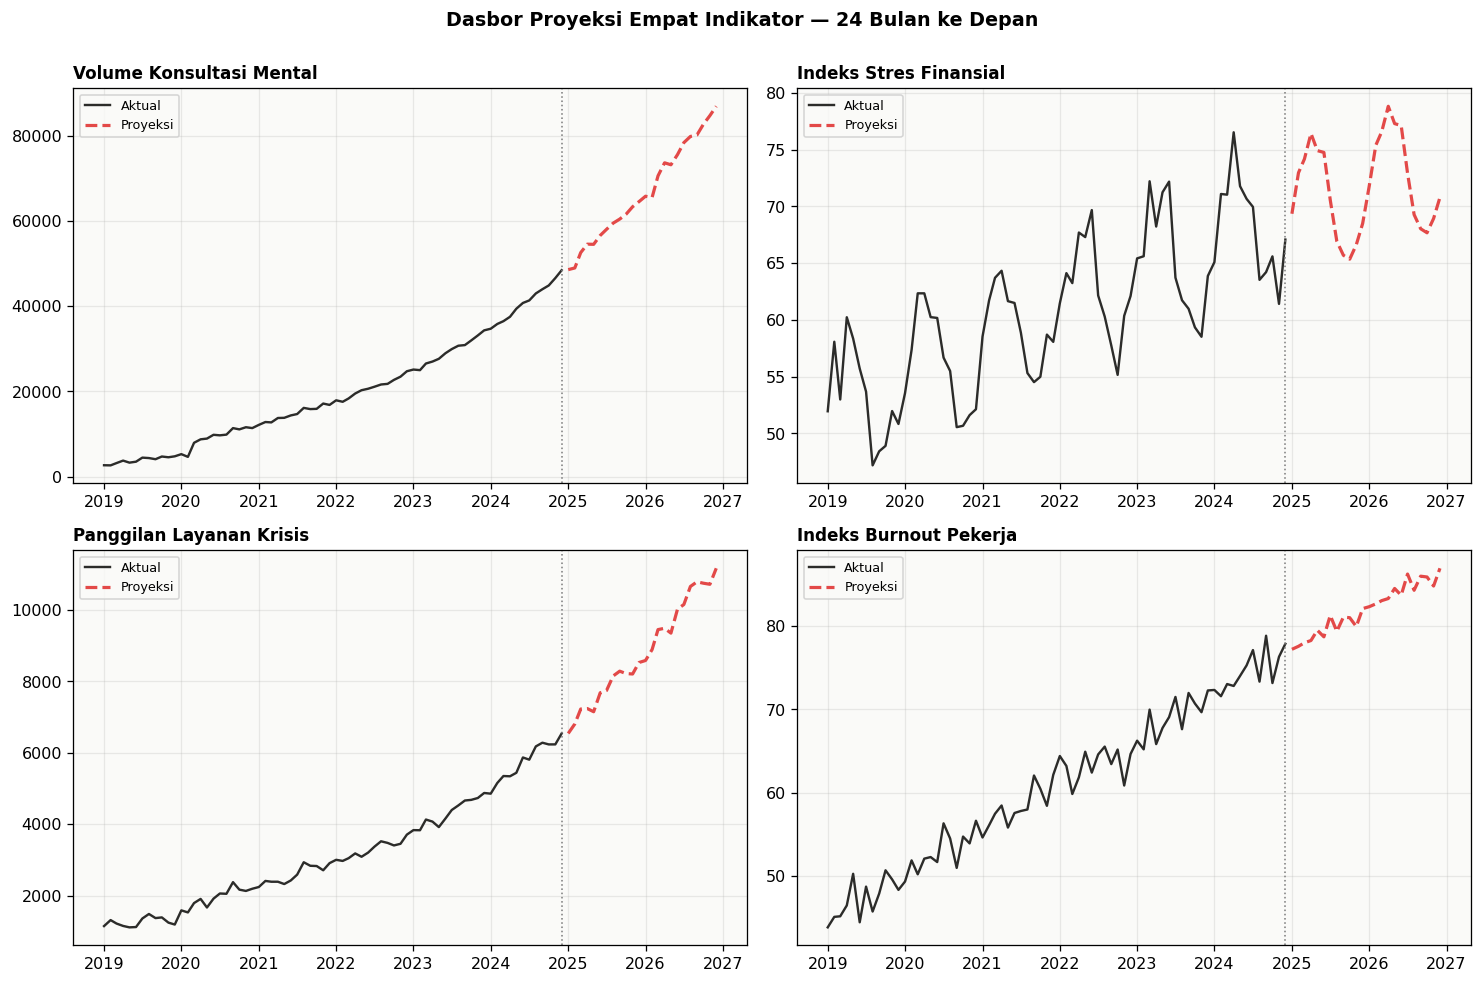

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8.5))
kolom_proy = {'ensemble': Y_COL, 'indeks_stres_finansial': 'indeks_stres_finansial',
             'panggilan_krisis_psikologis': 'panggilan_krisis_psikologis',
             'indeks_burnout_pekerja': 'indeks_burnout_pekerja'}
for ax, (kp, ka) in zip(axes.ravel(), kolom_proy.items()):
    ax.plot(m.index, m[ka], color=PALETTE['dark'], lw=1.5, label='Aktual')
    ax.plot(proyeksi.index, proyeksi[kp], color=PALETTE['danger'], lw=2, ls='--', label='Proyeksi')
    ax.axvline(m.index[-1], color='grey', lw=1, ls=':')
    ax.set_title(LABEL[ka], fontsize=10.5, loc='left'); ax.legend(fontsize=8)
fig.suptitle('Dasbor Proyeksi Empat Indikator — 24 Bulan ke Depan', fontweight='bold', y=1.0)
plt.tight_layout()
fig.savefig(f'{SVG_DIR}/06_dasbor_semua_indikator.svg', format='svg', bbox_inches='tight')
plt.show()

## 12. Ekspor

In [31]:
proyeksi.round(3).to_csv('hasil_proyeksi_24bulan.csv')
ringkas_cv.round(4).to_csv('hasil_perbandingan_model_cv.csv')
cv.round(4).to_csv('hasil_skor_per_window.csv', index=False)
robust.round(4).to_csv('hasil_robustness_covid.csv', index=False)

print('Berkas tersimpan:')
for f in sorted(os.listdir(SVG_DIR)):
    print(f'  {SVG_DIR}/' + f)
for f in ['hasil_proyeksi_24bulan.csv','hasil_perbandingan_model_cv.csv','hasil_skor_per_window.csv',
         'hasil_robustness_covid.csv']:
    print('  ' + f)

Berkas tersimpan:
  figures_svg/00_empat_seri.svg
  figures_svg/01_stl_dekomposisi.svg
  figures_svg/02_perbandingan_model_cv.svg
  figures_svg/02b_skor_per_window.svg
  figures_svg/03_robustness_dummy_covid.svg
  figures_svg/04_fanchart_12bulan.svg
  figures_svg/05_fanchart_24bulan.svg
  figures_svg/06_dasbor_semua_indikator.svg
  figures_svg/fanchart_03bulan.svg
  figures_svg/fanchart_06bulan.svg
  figures_svg/forecast_model_terbaik_03bulan.svg
  figures_svg/forecast_model_terbaik_06bulan.svg
  figures_svg/forecast_model_terbaik_12bulan.svg
  figures_svg/forecast_model_terbaik_24bulan.svg
  hasil_proyeksi_24bulan.csv
  hasil_perbandingan_model_cv.csv
  hasil_skor_per_window.csv
  hasil_robustness_covid.csv


## 13. Ringkasan Otomatis

In [32]:
print('1) PEMILIHAN MODEL (Walk-Forward CV)')
for h in HORIZONS:
    t = ringkas_cv.xs(h, level='h').sort_values('mape')
    print(f'   h={h:>2d} bulan: terbaik = {t.index[0]:<28s} MAPE={t.iloc[0]["mape"]:.2f}%  '
          f'(pembanding termudah Seasonal-Naive+drift: {t.loc["Seasonal-Naive+drift","mape"]:.2f}%)')
print(f'   Model juara keseluruhan (rata-rata peringkat kedua horizon): "{BEST_MODEL_NAME}"')

print(f'\n2) STRUKTUR DATA')
print(f'   Kekuatan tren={kekuatan_tren:.2f}, kekuatan musiman={kekuatan_musim:.2f} (dekomposisi STL)')
print(f'   Orde SARIMA final: ({ORDE_FINAL[0]},{ORDE_FINAL[1]},{ORDE_FINAL[2]})x{SEASONAL_ORDER}')
print(f'   Residual model final: {"white noise (Ljung-Box p>0.05)" if _lb_ok else "masih ada autokorelasi tersisa"}')

print(f'\n3) STRUCTURAL BREAK COVID-19')
print(f'   Skema regressor intervensi terbaik: "{_skema_terbaik}"')
print(f'   Titik anomali residual (|z|>2.5): {list(outlier.strftime("%Y-%m")) if len(outlier) else "tidak ada"}')

print(f'\n4) PROYEKSI {LABEL[Y_COL].upper()} (ensemble, lihat juga kolom model_terbaik utk "{BEST_MODEL_NAME}" saja)')
for tonjolan in [3, 6, 12, 24]:
    r = proyeksi.iloc[tonjolan-1]
    print(f'   +{tonjolan:>2d} bulan ({r.name.strftime("%Y-%m")}): ensemble={r.ensemble:,.0f}  '
          f'CI95=[{r.ci95_bawah:,.0f}, {r.ci95_atas:,.0f}]  |  {BEST_MODEL_NAME}={r.model_terbaik:,.0f}')
print(f'   Pertumbuhan kumulatif 24 bulan: {pertumbuhan:+.1f}%')

print('\n5) INDIKATOR SEKUNDER (+24 bulan)')
for kp, ka in kolom_proy.items():
    if kp == 'ensemble': continue
    print(f'   {LABEL[ka]:<28s} {m[ka].iloc[-1]:>9,.1f} -> {proyeksi[kp].iloc[-1]:>9,.1f}')

print('\nKETERBATASAN YANG PERLU DINYATAKAN TERBUKA')
print('  - Data adalah simulasi (bukan hasil pencatatan administratif riil); pola COVID-19')
print('    dibuat eksplisit secara sintetis, sehingga temuan robustness bersifat ilustratif.')
print(f'  - Pertumbuhan historis 2019-2024 mengandung komponen eksponensial (bukan sekadar')
print(f'    linear), dan model mengekstrapolasi pola itu apa adanya (+{pertumbuhan:.0f}% dalam 24')
print(f'    bulan). Pertumbuhan eksponensial jarang bertahan tanpa batas di dunia nyata --')
print(f'    proyeksi jangka panjang (>12 bulan) sebaiknya dibaca sebagai skenario "jika tren')
print(f'    berlanjut", bukan titik tunggal yang pasti terjadi.')
print('  - `panggilan_krisis_psikologis` diramalkan berjenjang dari proyeksi volume sendiri;')
print('    ketidakpastian proyeksi volume ikut menjalar dan tidak sepenuhnya tercermin di CI-nya.')
print('  - CI fan chart memakai distribusi SARIMA, bukan gabungan formal tiga model ensemble;')
print('    lebar sesungguhnya kemungkinan sedikit lebih besar dari yang ditunjukkan.')
print('  - 72 titik data tetap tergolong pendek untuk SARIMA musiman (idealnya >=5-6 siklus,')
print('    di sini hanya 6); orde musiman ditentukan sekali di awal, bukan re-grid tiap fold.')

1) PEMILIHAN MODEL (Walk-Forward CV)
   h= 3 bulan: terbaik = SARIMA                       MAPE=3.39%  (pembanding termudah Seasonal-Naive+drift: 23.01%)
   h=12 bulan: terbaik = SARIMAX (+driver)            MAPE=4.37%  (pembanding termudah Seasonal-Naive+drift: 25.21%)
   Model juara keseluruhan (rata-rata peringkat kedua horizon): "SARIMA"

2) STRUKTUR DATA
   Kekuatan tren=1.00, kekuatan musiman=0.31 (dekomposisi STL)
   Orde SARIMA final: (2,1,2)x(0, 1, 1, 12)
   Residual model final: masih ada autokorelasi tersisa

3) STRUCTURAL BREAK COVID-19
   Skema regressor intervensi terbaik: "Step (0/1 sejak onset)"
   Titik anomali residual (|z|>2.5): ['2019-01', '2020-01']

4) PROYEKSI VOLUME KONSULTASI MENTAL (ensemble, lihat juga kolom model_terbaik utk "SARIMA" saja)
   + 3 bulan (2025-03): ensemble=52,575  CI95=[47,335, 55,930]  |  SARIMA=51,454
   + 6 bulan (2025-06): ensemble=56,594  CI95=[50,776, 64,376]  |  SARIMA=57,173
   +12 bulan (2025-12): ensemble=64,520  CI95=[57,361, 80,27